In [2]:
import datetime as dt
from tropycal import tracks, utils
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
county = gpd.read_file('Polygon/Unitedstates_county.shp')

In [4]:
state = county.dissolve(by='STATE')

In [5]:
#Louisiana boundary
la = state[state['ST_ABBR']=='LA']
fl = state[state['ST_ABBR']=='FL']
tx = state[state['ST_ABBR']=='TX']
ny = state[state['ST_ABBR']=='NY']
nj = state[state['ST_ABBR']=='NJ']
ct = state[state['ST_ABBR']=='CT']
sc = state[state['ST_ABBR']=='SC']
nc = state[state['ST_ABBR']=='NC']
la_mercator = la.to_crs(epsg=4326)
tx_mercator = tx.to_crs(epsg=4326)
fl_mercator = fl.to_crs(epsg=4326)
ny_mercator = ny.to_crs(epsg=4326)
nj_mercator = nj.to_crs(epsg=4326)
ct_mercator = ct.to_crs(epsg=4326)
sc_mercator = sc.to_crs(epsg=4326)
nc_mercator = nc.to_crs(epsg=4326)

In [6]:
basin = tracks.TrackDataset(basin='north_atlantic',include_btk=True)

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (1.04 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (2.47 seconds)


In [7]:
proj = ccrs.PlateCarree()

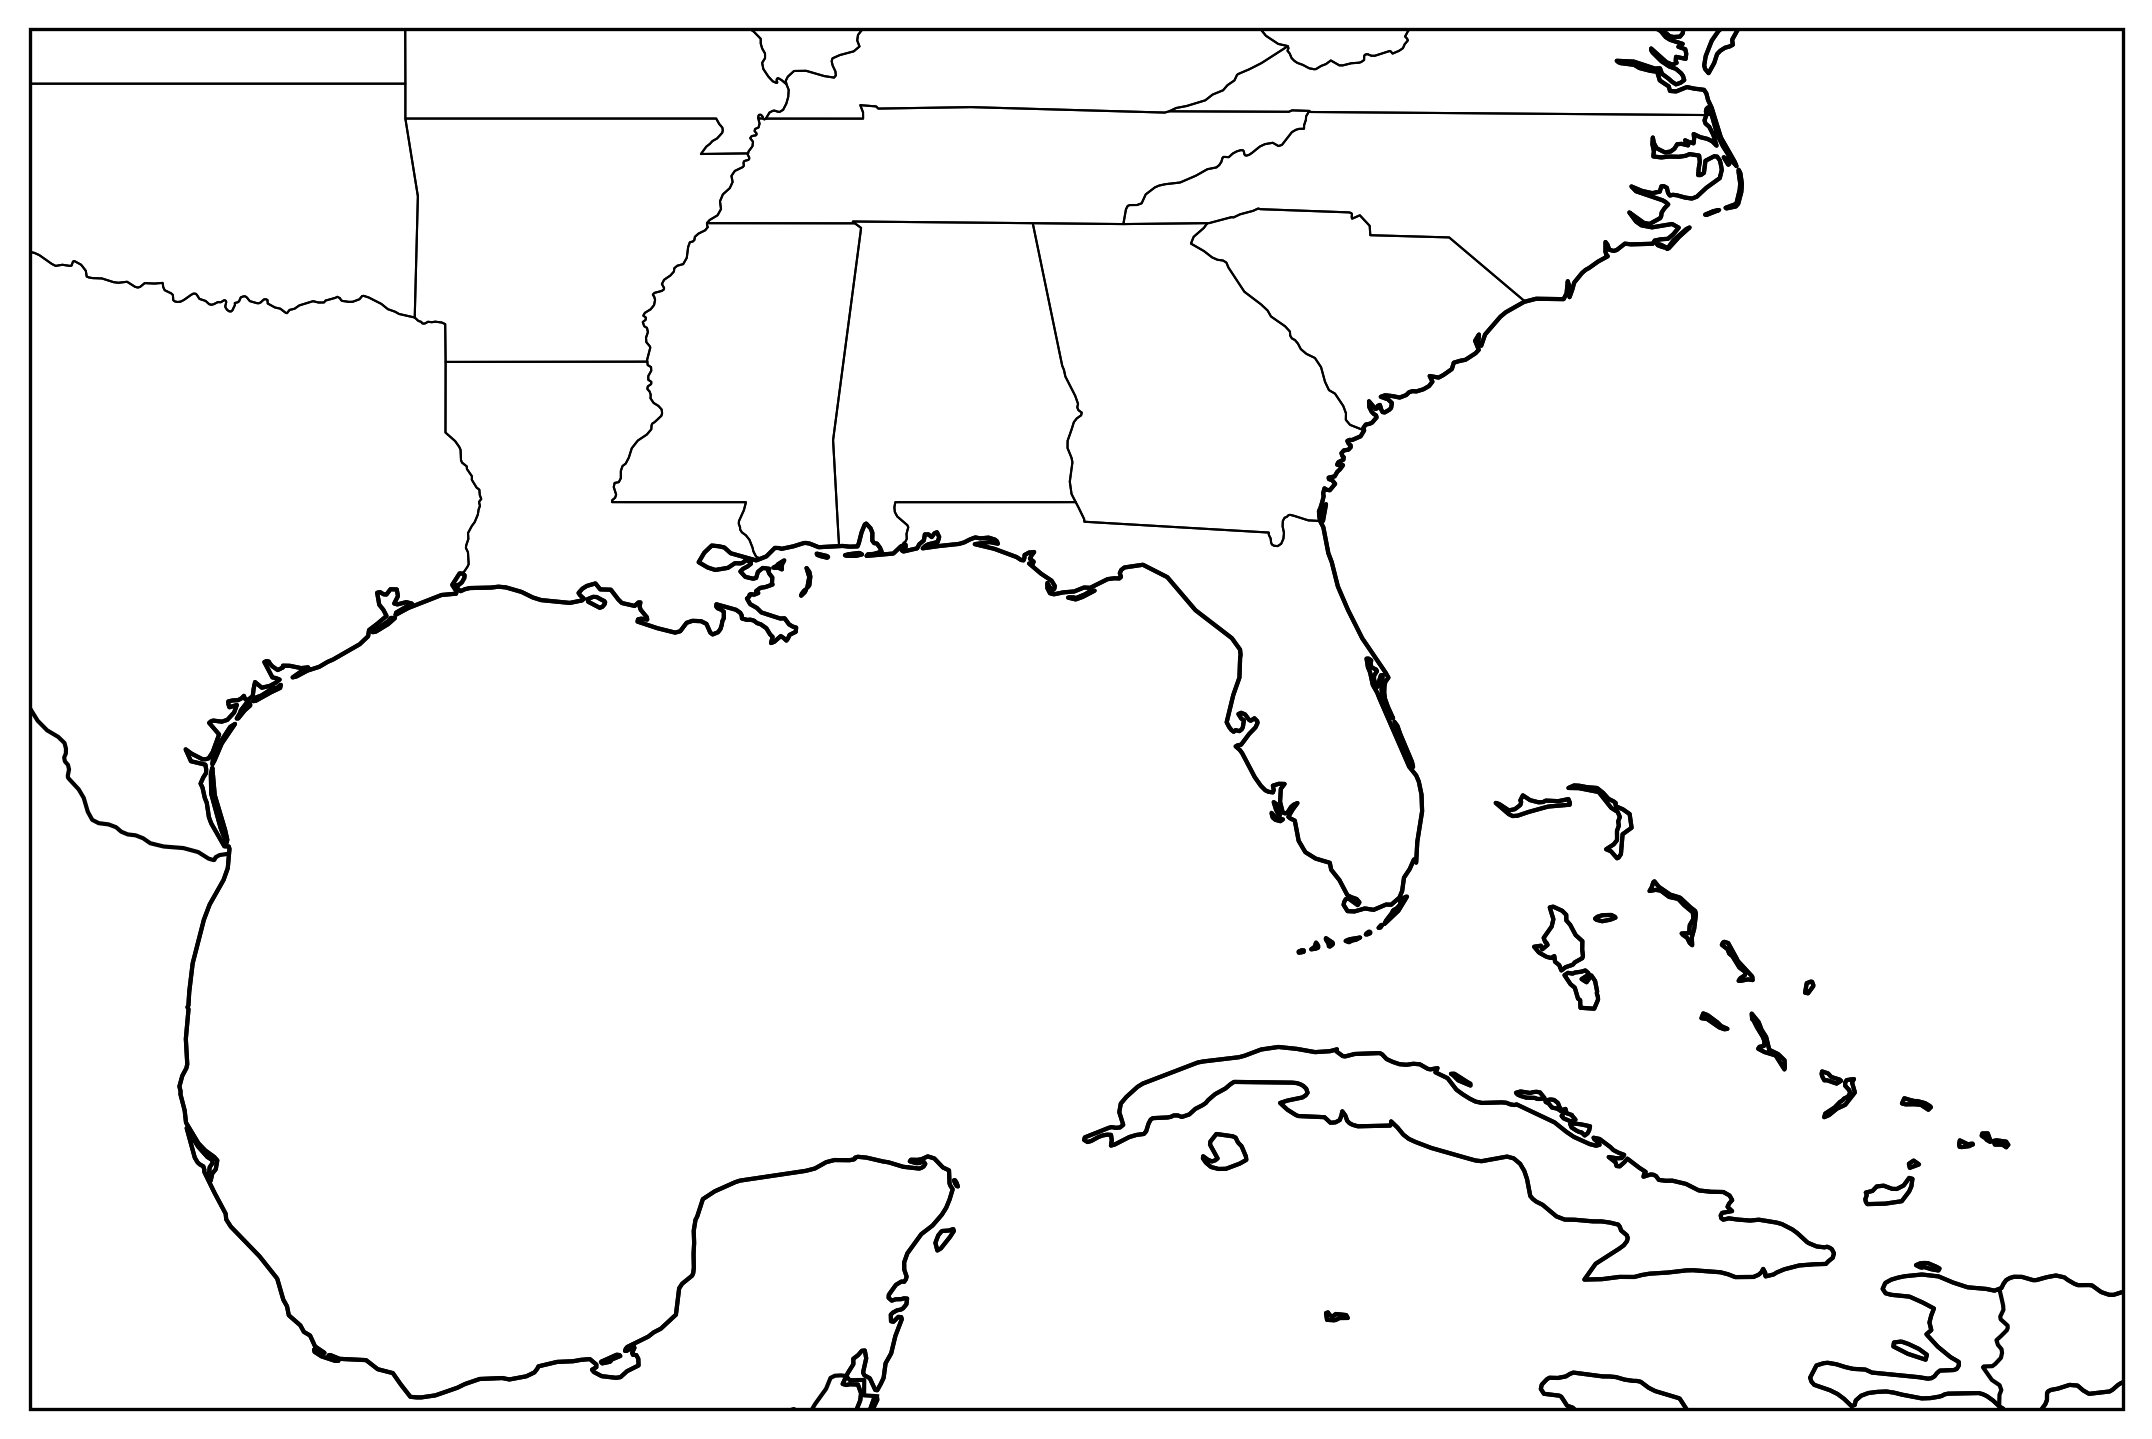

In [8]:
# Create an instance of figure and axes
fig = plt.figure(figsize=(9,6),dpi=300)
ax = plt.axes(projection=proj)

# Plot coastlines and political boundaries
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidths=0.5, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidths=1.0, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidths=1.0, linestyle='solid', edgecolor='k')

# Fill in continents in light gray
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='white', edgecolor='k')

# Zoom in over the Gulf Coast
ax.set_extent([-100,-70,18,37])

In [9]:
def plot_boundaries(ax):
    """This function plots geographic and political boundaries on the provided axes."""

    # Plot coastlines and political boundaries
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidths=0.5, linestyle='solid', edgecolor='k')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidths=1.0, linestyle='solid', edgecolor='k')
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidths=1.0, linestyle='solid', edgecolor='k')

    # Fill in continents in light gray
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='white', edgecolor='face')

    # Return axes instance
    return ax

# LA delta

In [10]:
storm = basin.get_storm(('delta',2020))
requested_time = dt.datetime(2020, 10, 6, 18)
cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

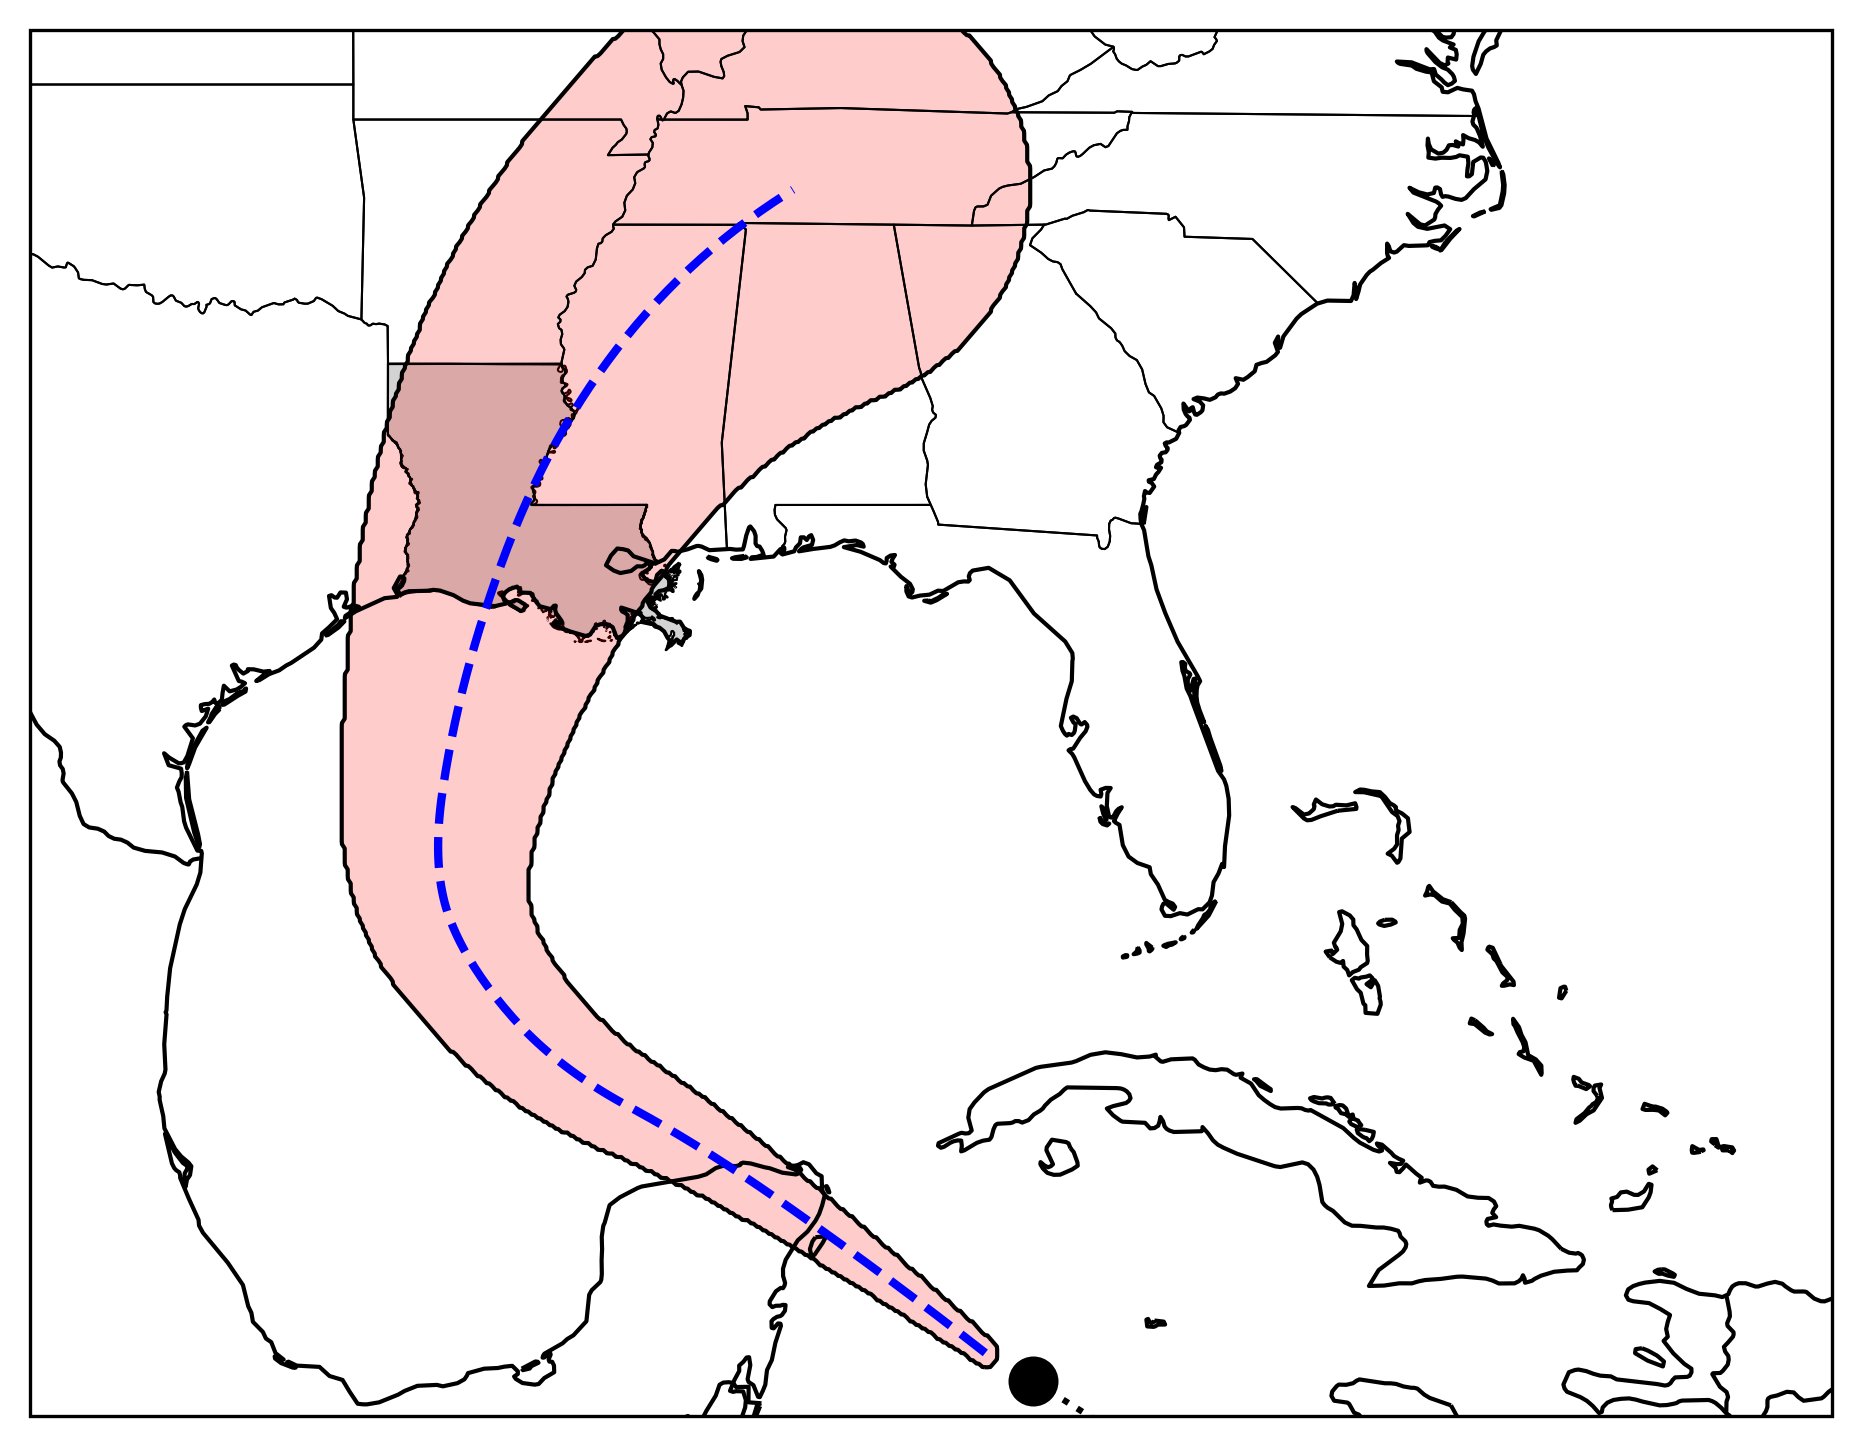

In [11]:
# Create an instance of figure and axes
fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)

ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
la_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())
ax.set_extent([-100,-70,18,37])

# LA zeta

In [12]:
storm = basin.get_storm(('zeta',2020))

requested_time = dt.datetime(2020, 10, 26, 18)
cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

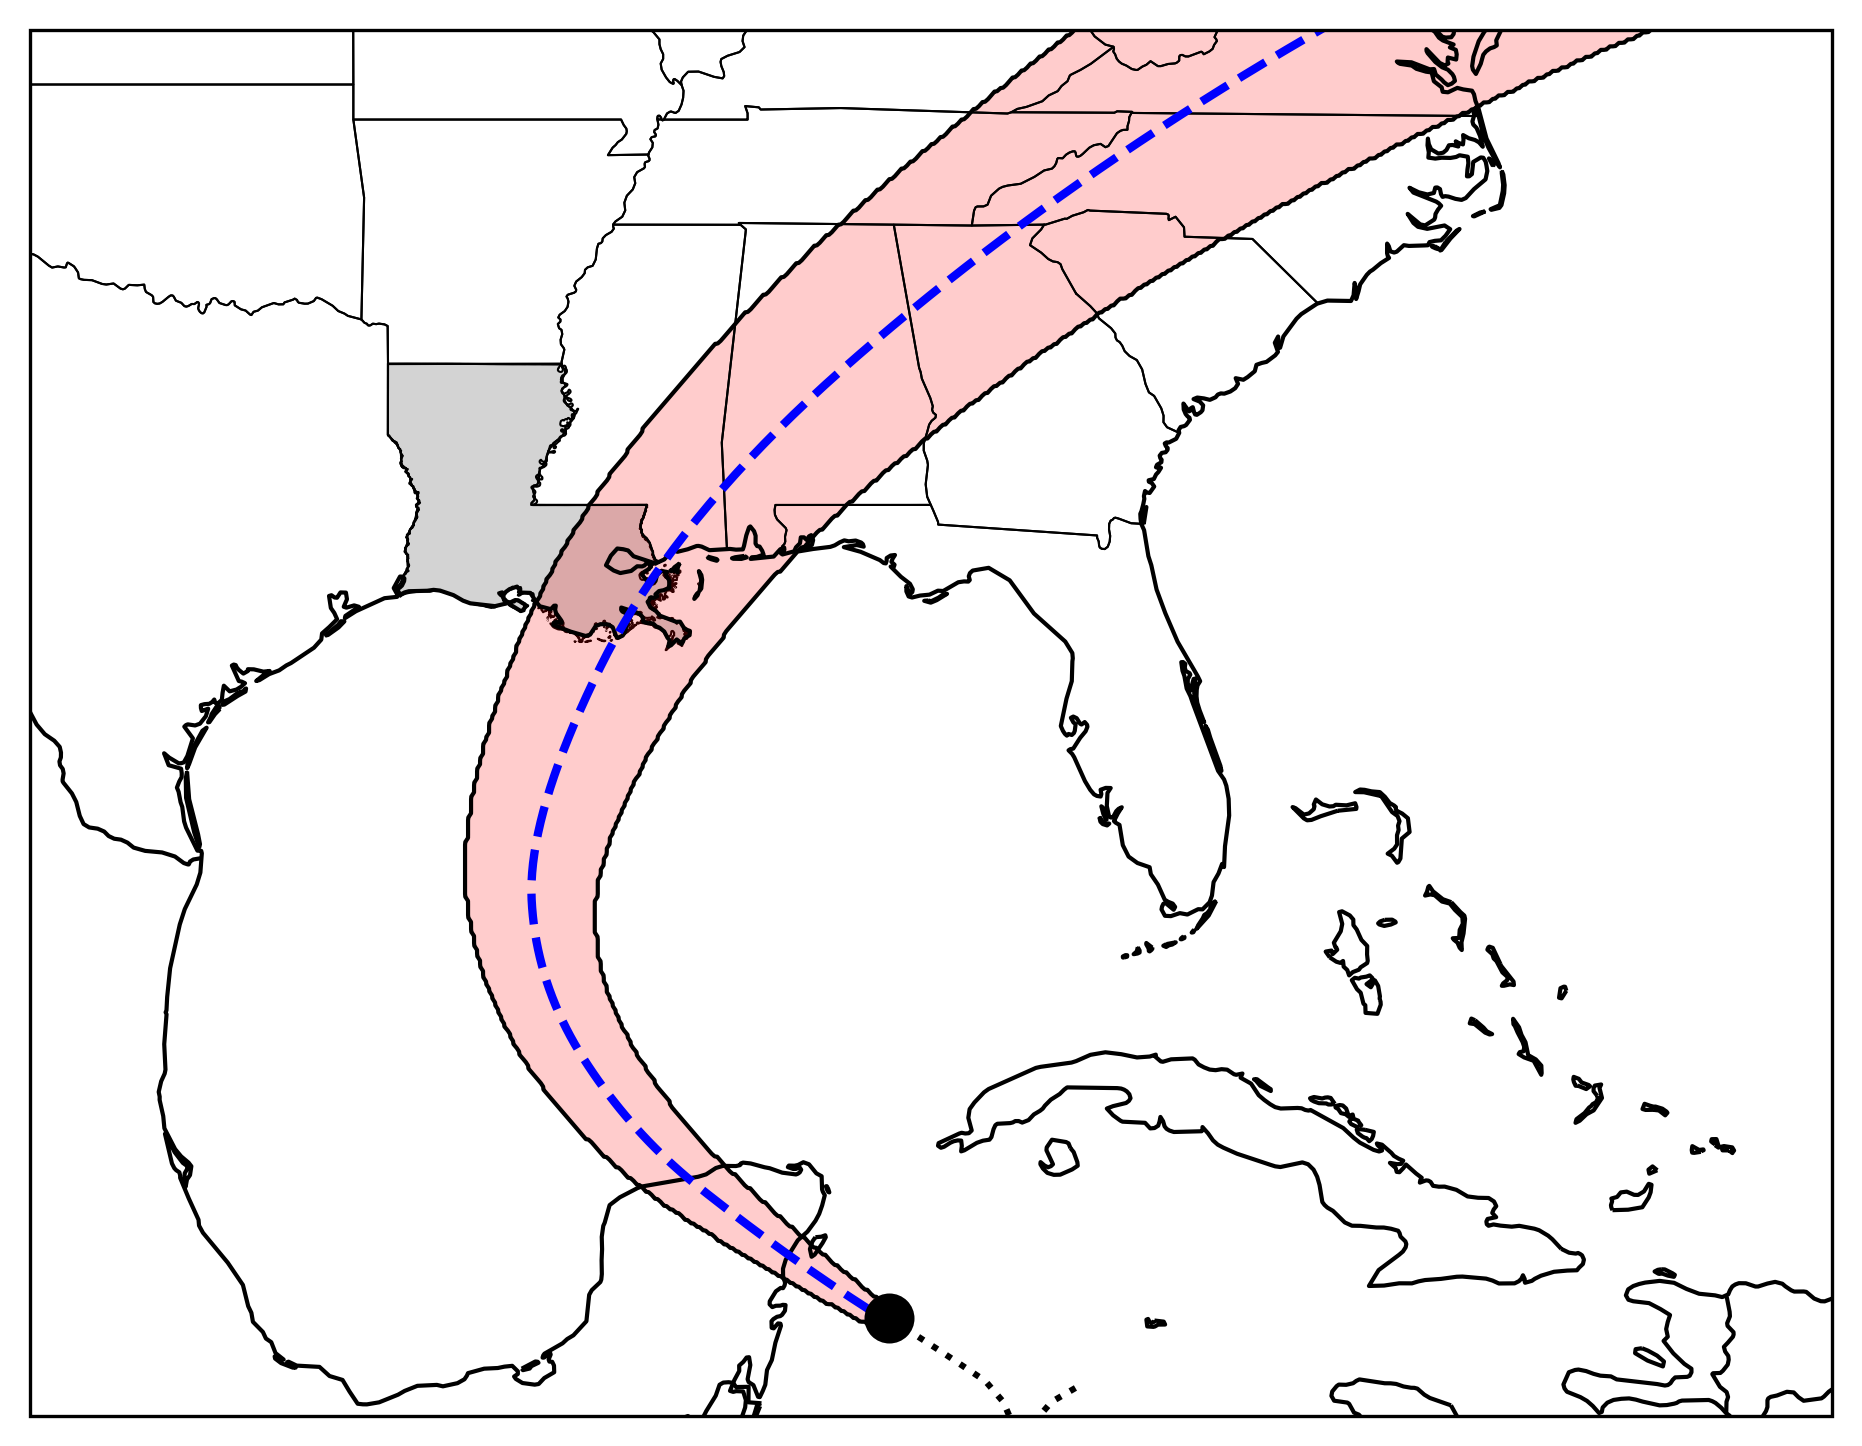

In [13]:
fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
la_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-100,-70,18,37])


# TX Delta

In [14]:
storm = basin.get_storm(('delta',2020))

# Retrieve desired forecast
requested_time = dt.datetime(2020, 10, 6, 18)

#Create cone dict using default settings
cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

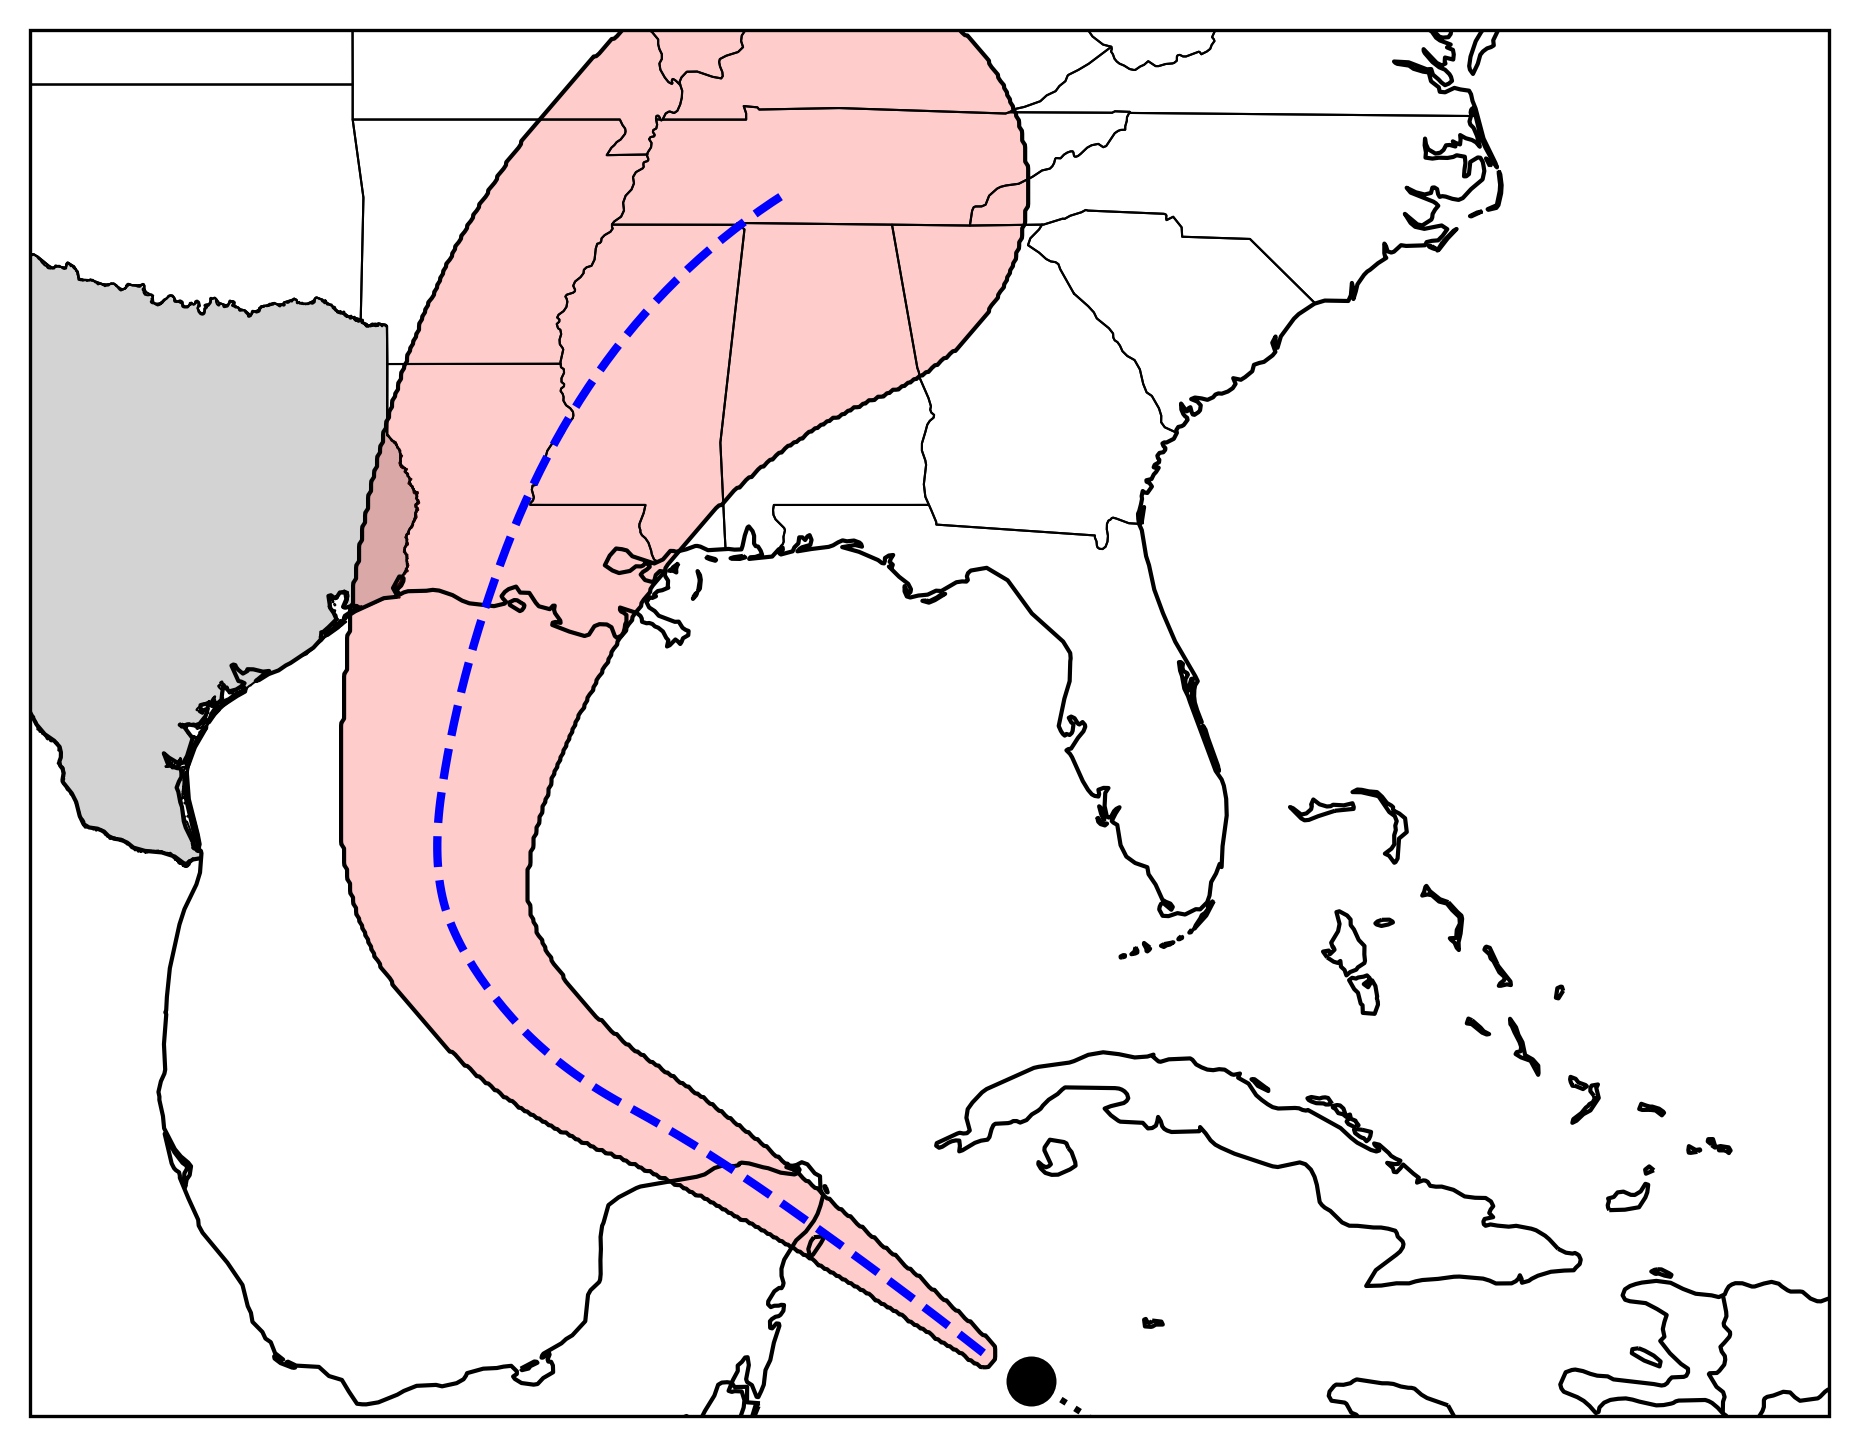

In [15]:
fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
tx_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-100,-70,18,37])

# TX beta

In [16]:
storm = basin.get_storm(('beta',2020))

# Retrieve desired forecast
requested_time = dt.datetime(2020, 9, 19, 12)

#Create cone dict using default settings
cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

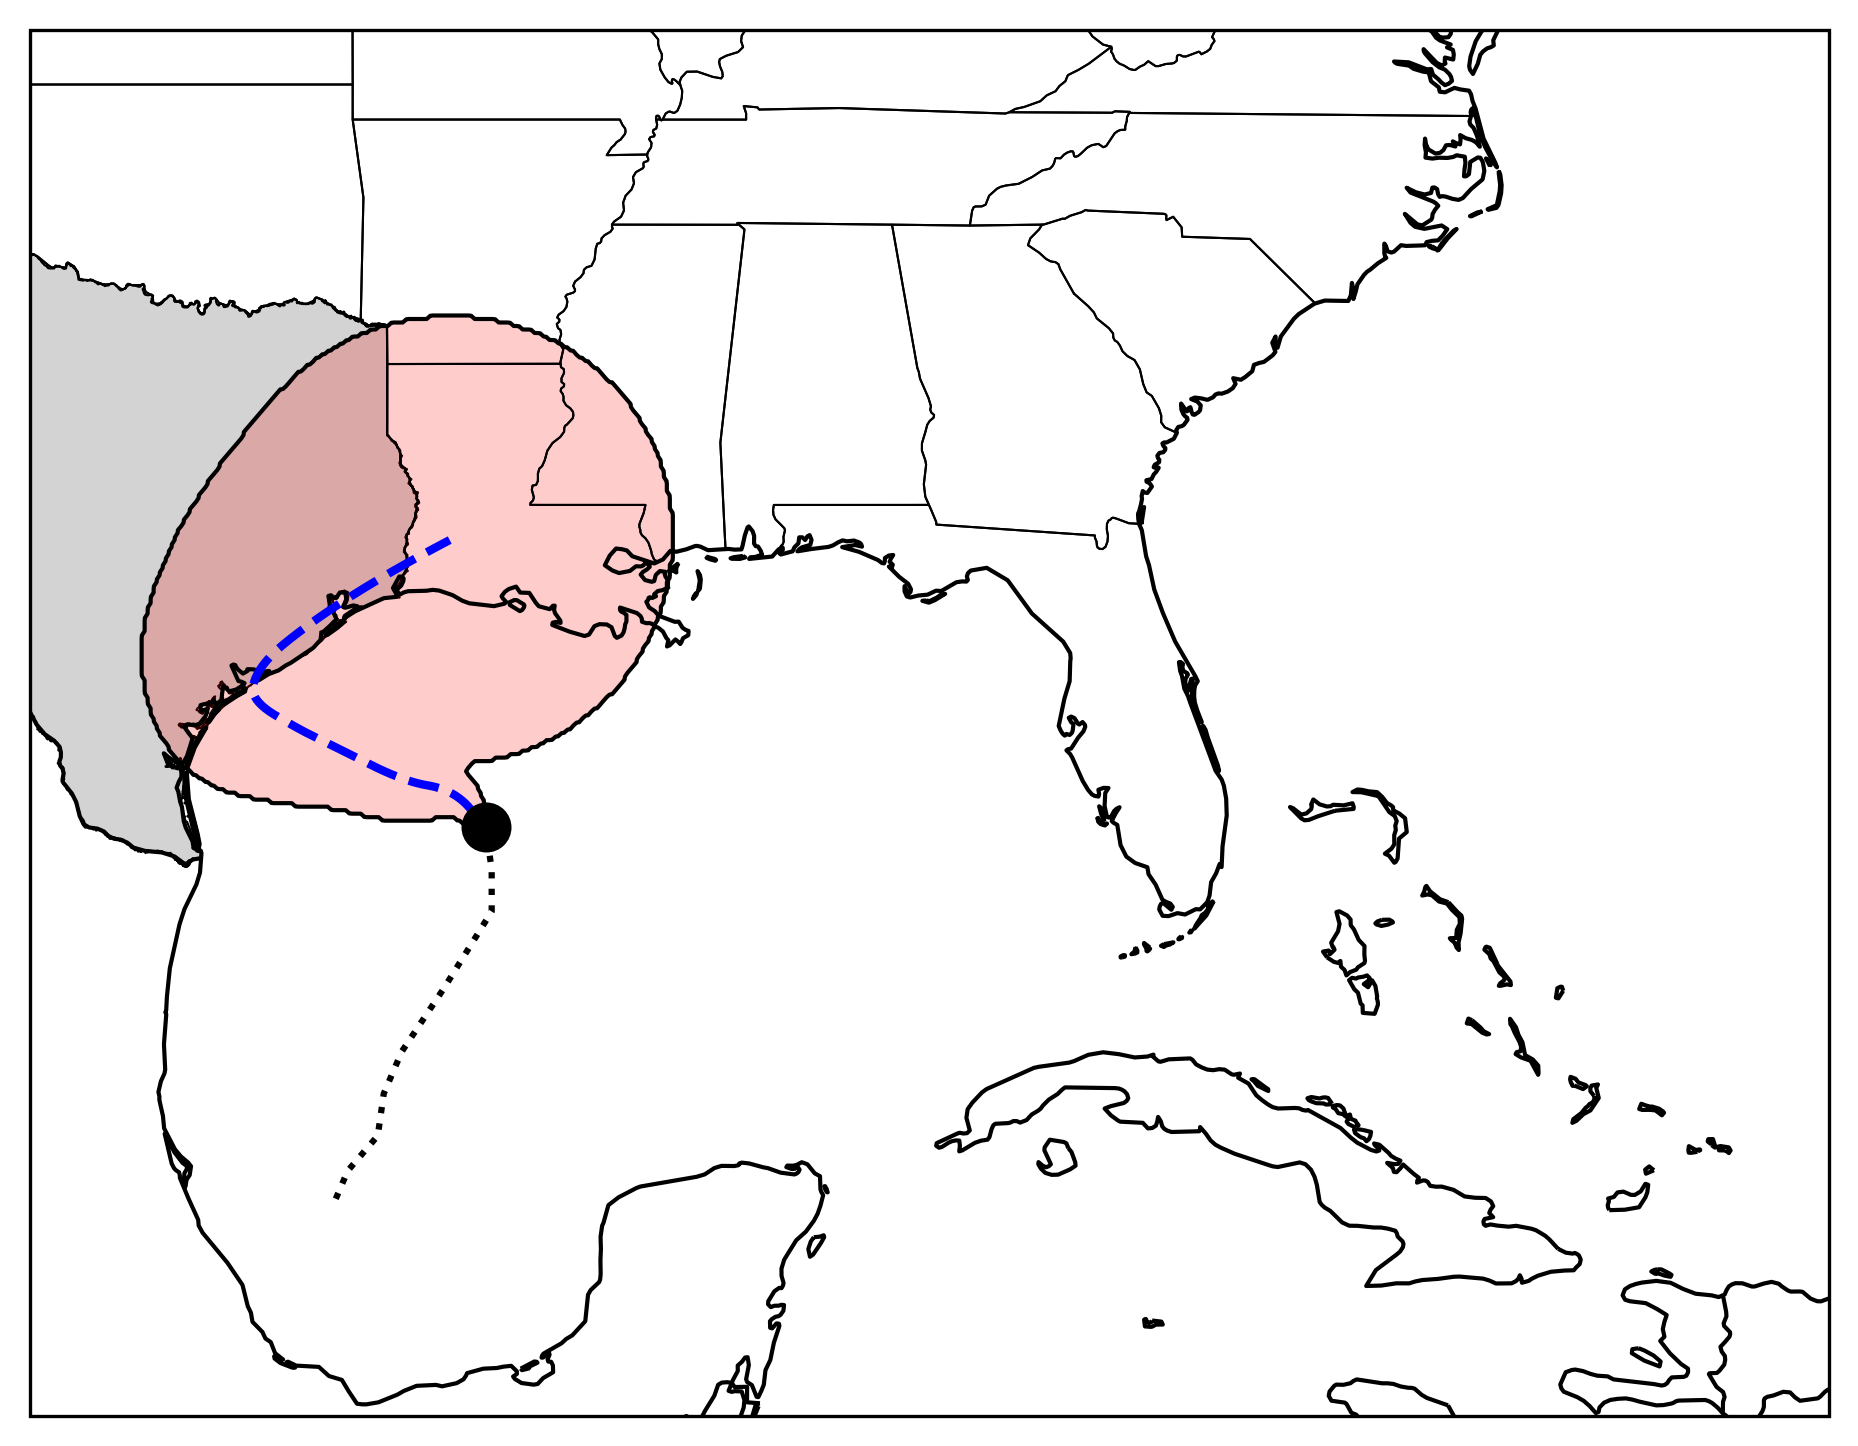

In [17]:
fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)

ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
tx_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

# Zoom in over the Gulf Coast
ax.set_extent([-100,-70,18,37])

In [18]:
print(ny_mercator.crs)
ny_mercator = ny_mercator.to_crs(proj.proj4_params)

EPSG:4326


# Claudette

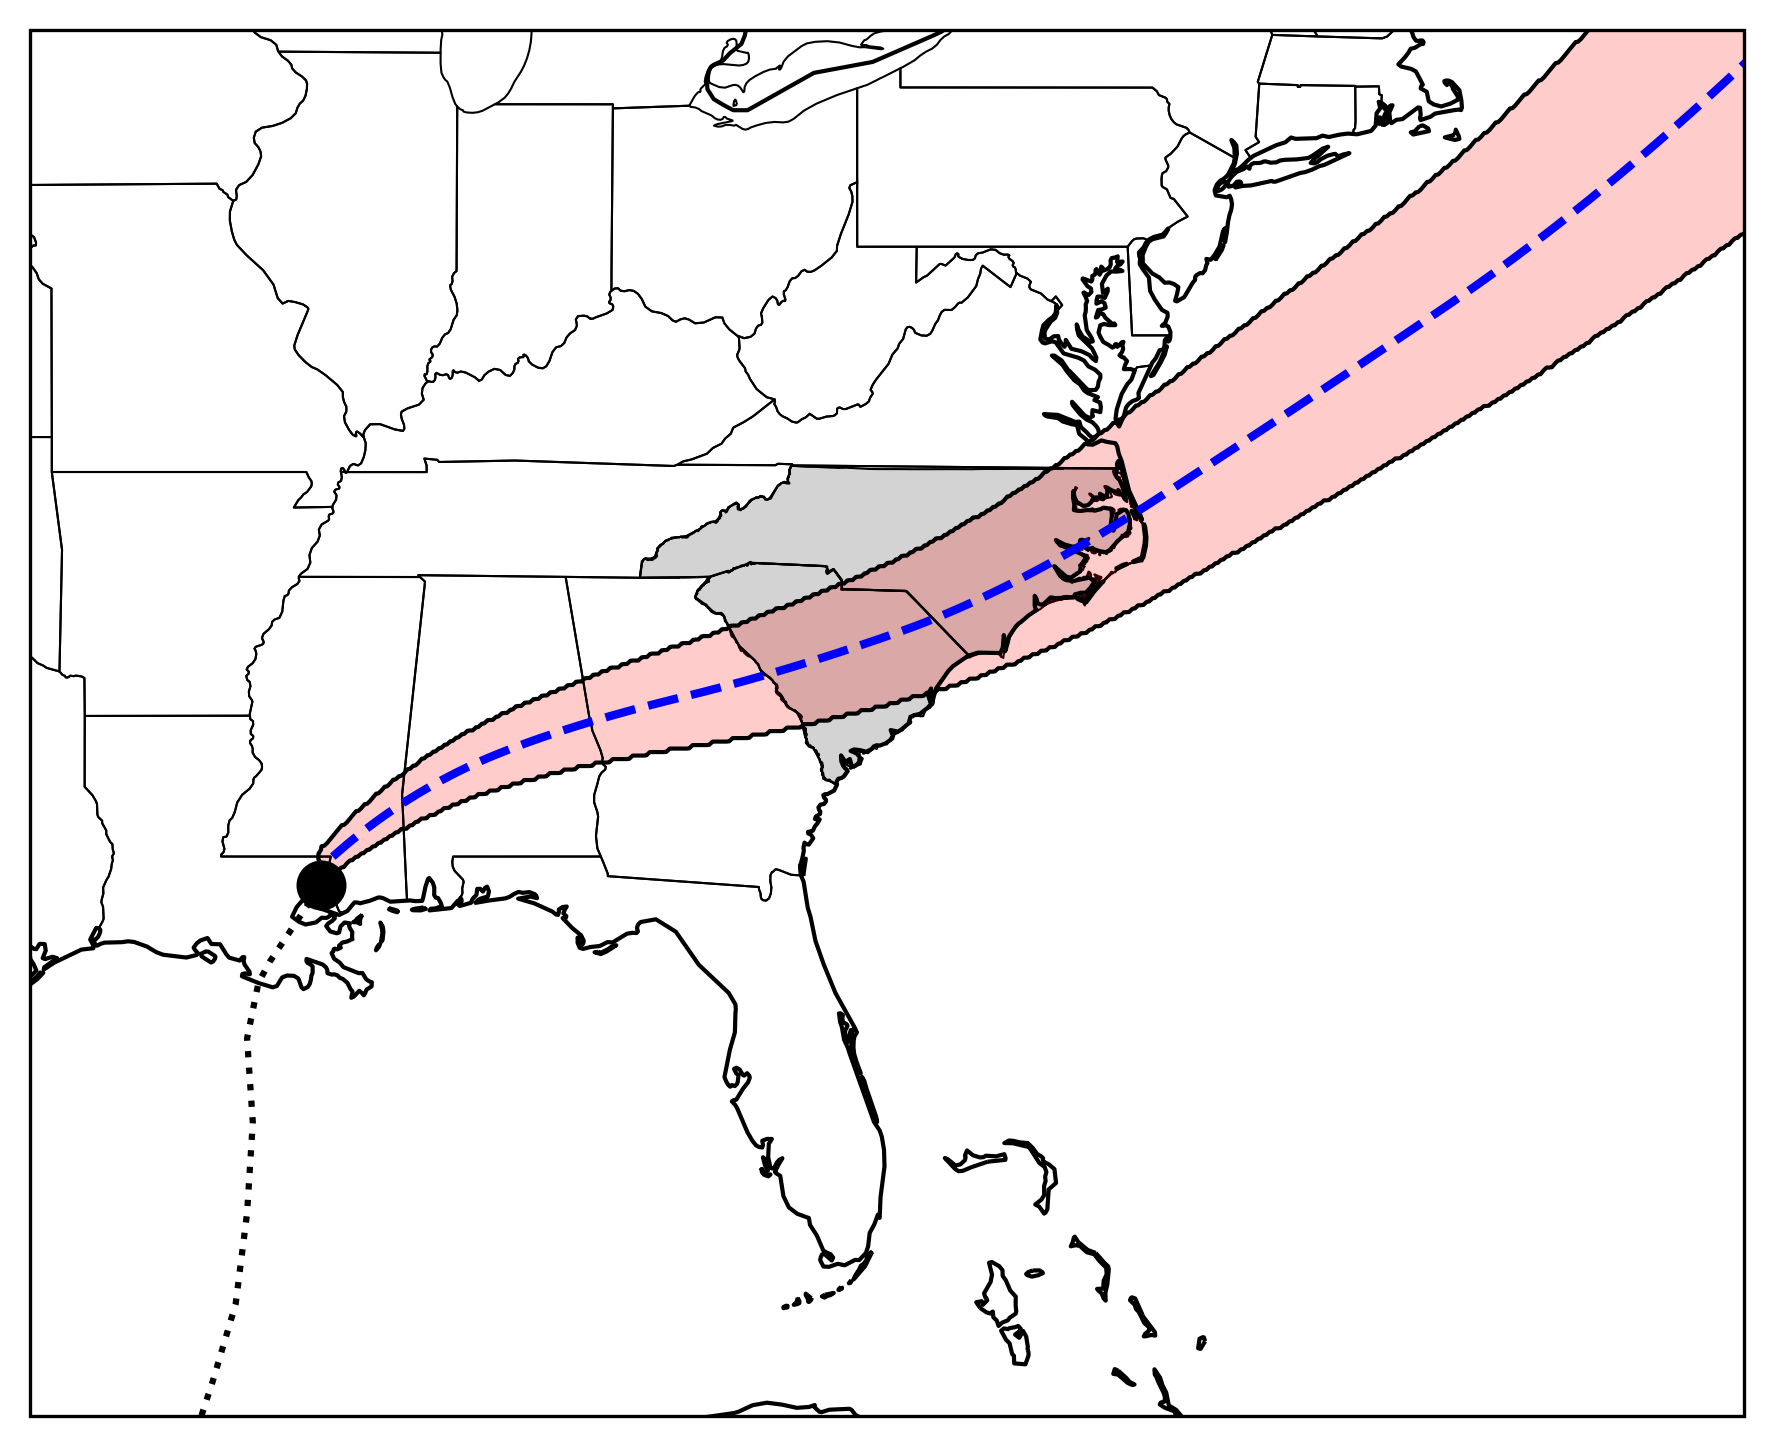

In [19]:
storm = basin.get_storm(('claudette',2021))

# Retrieve desired forecast
requested_time = dt.datetime(2021, 6, 19, 12)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) # We already defined "proj" earlier, so no need to redefine it
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
sc_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
nc_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())
ax.set_extent([-95,-65,23,42])

# Elsa

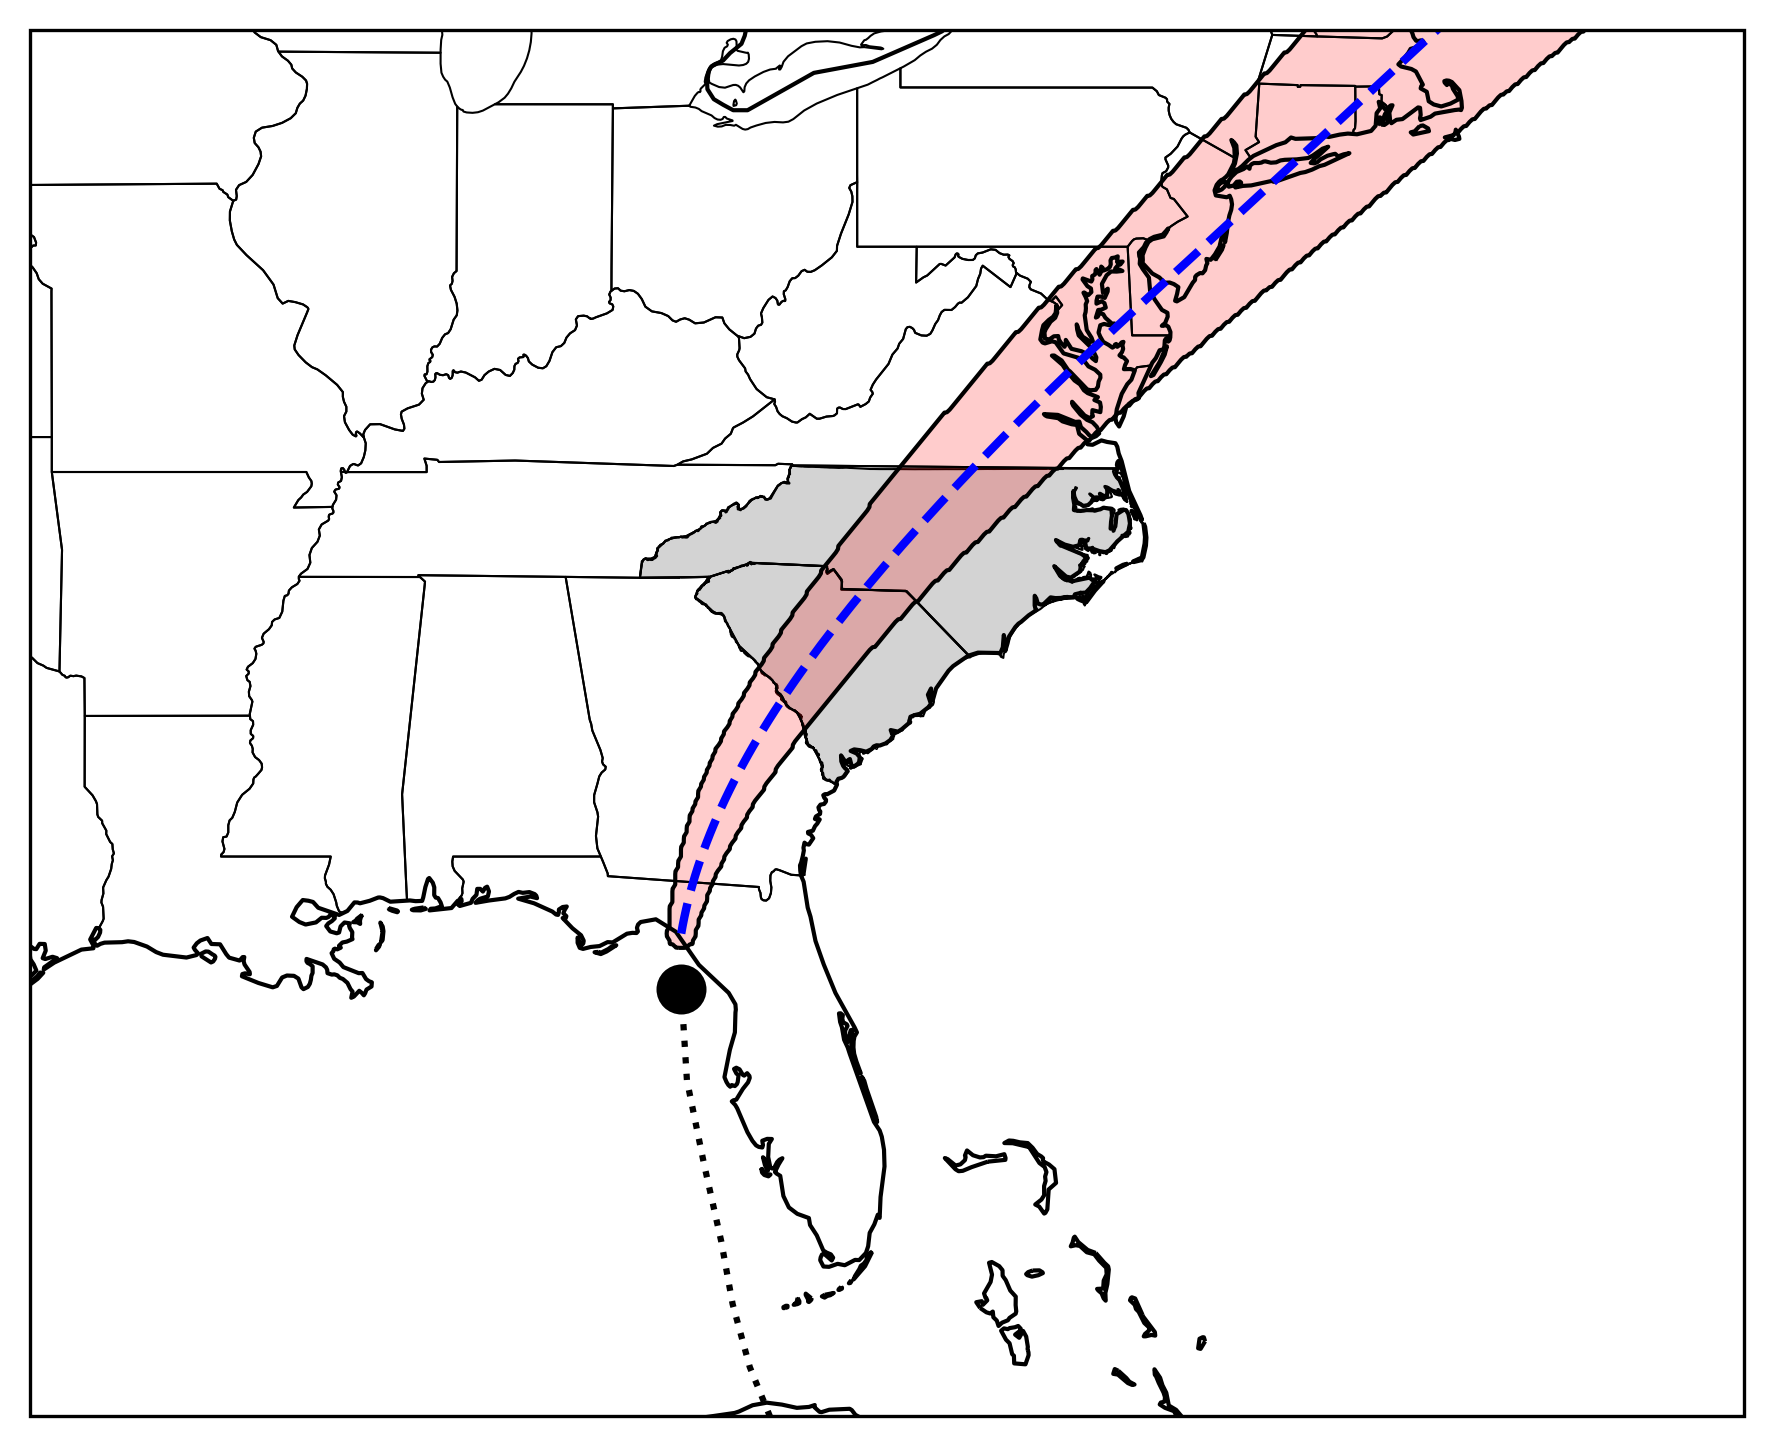

In [20]:
storm = basin.get_storm(('elsa',2021))

requested_time = dt.datetime(2021, 7, 7, 12)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) # We already defined "proj" earlier, so no need to redefine it
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)


storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
sc_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
nc_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-95,-65,23,42])

# Henri

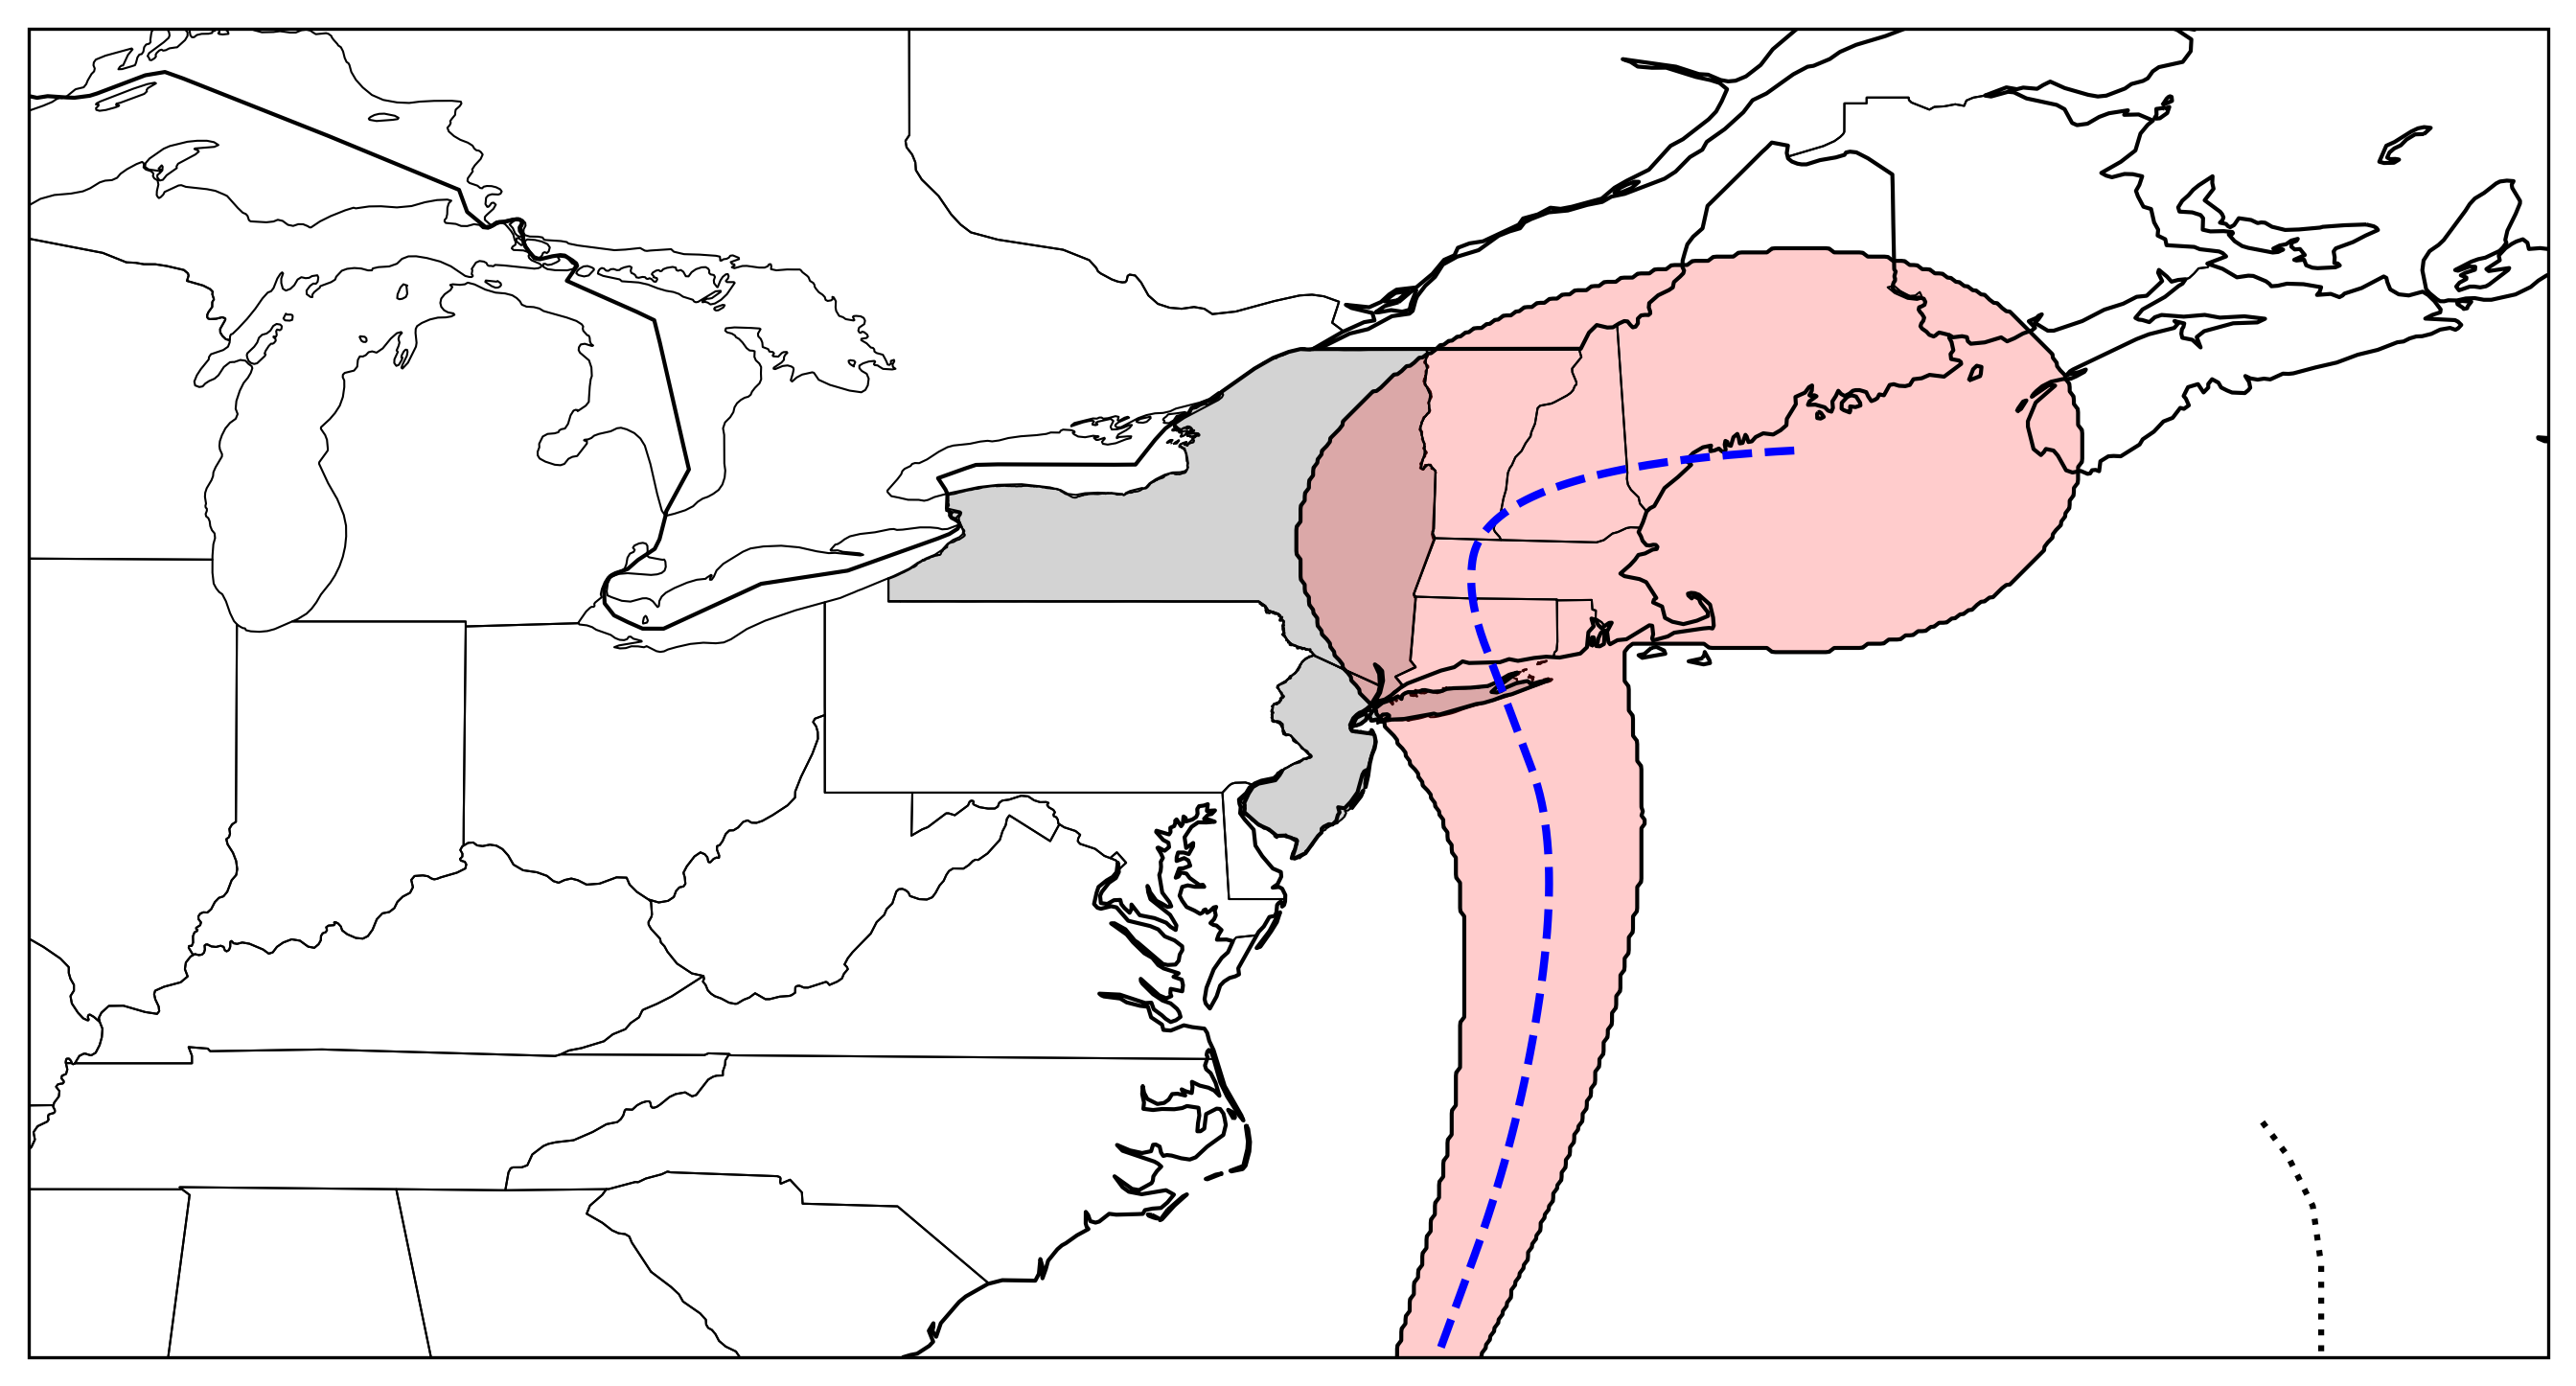

In [21]:
storm = basin.get_storm(('henri',2021))
requested_time = dt.datetime(2021, 8, 20, 18)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) # We already defined "proj" earlier, so no need to redefine it
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)


storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
nj_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
ny_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')


ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())
ax.set_extent([-90,-60,33,48])

# Ida

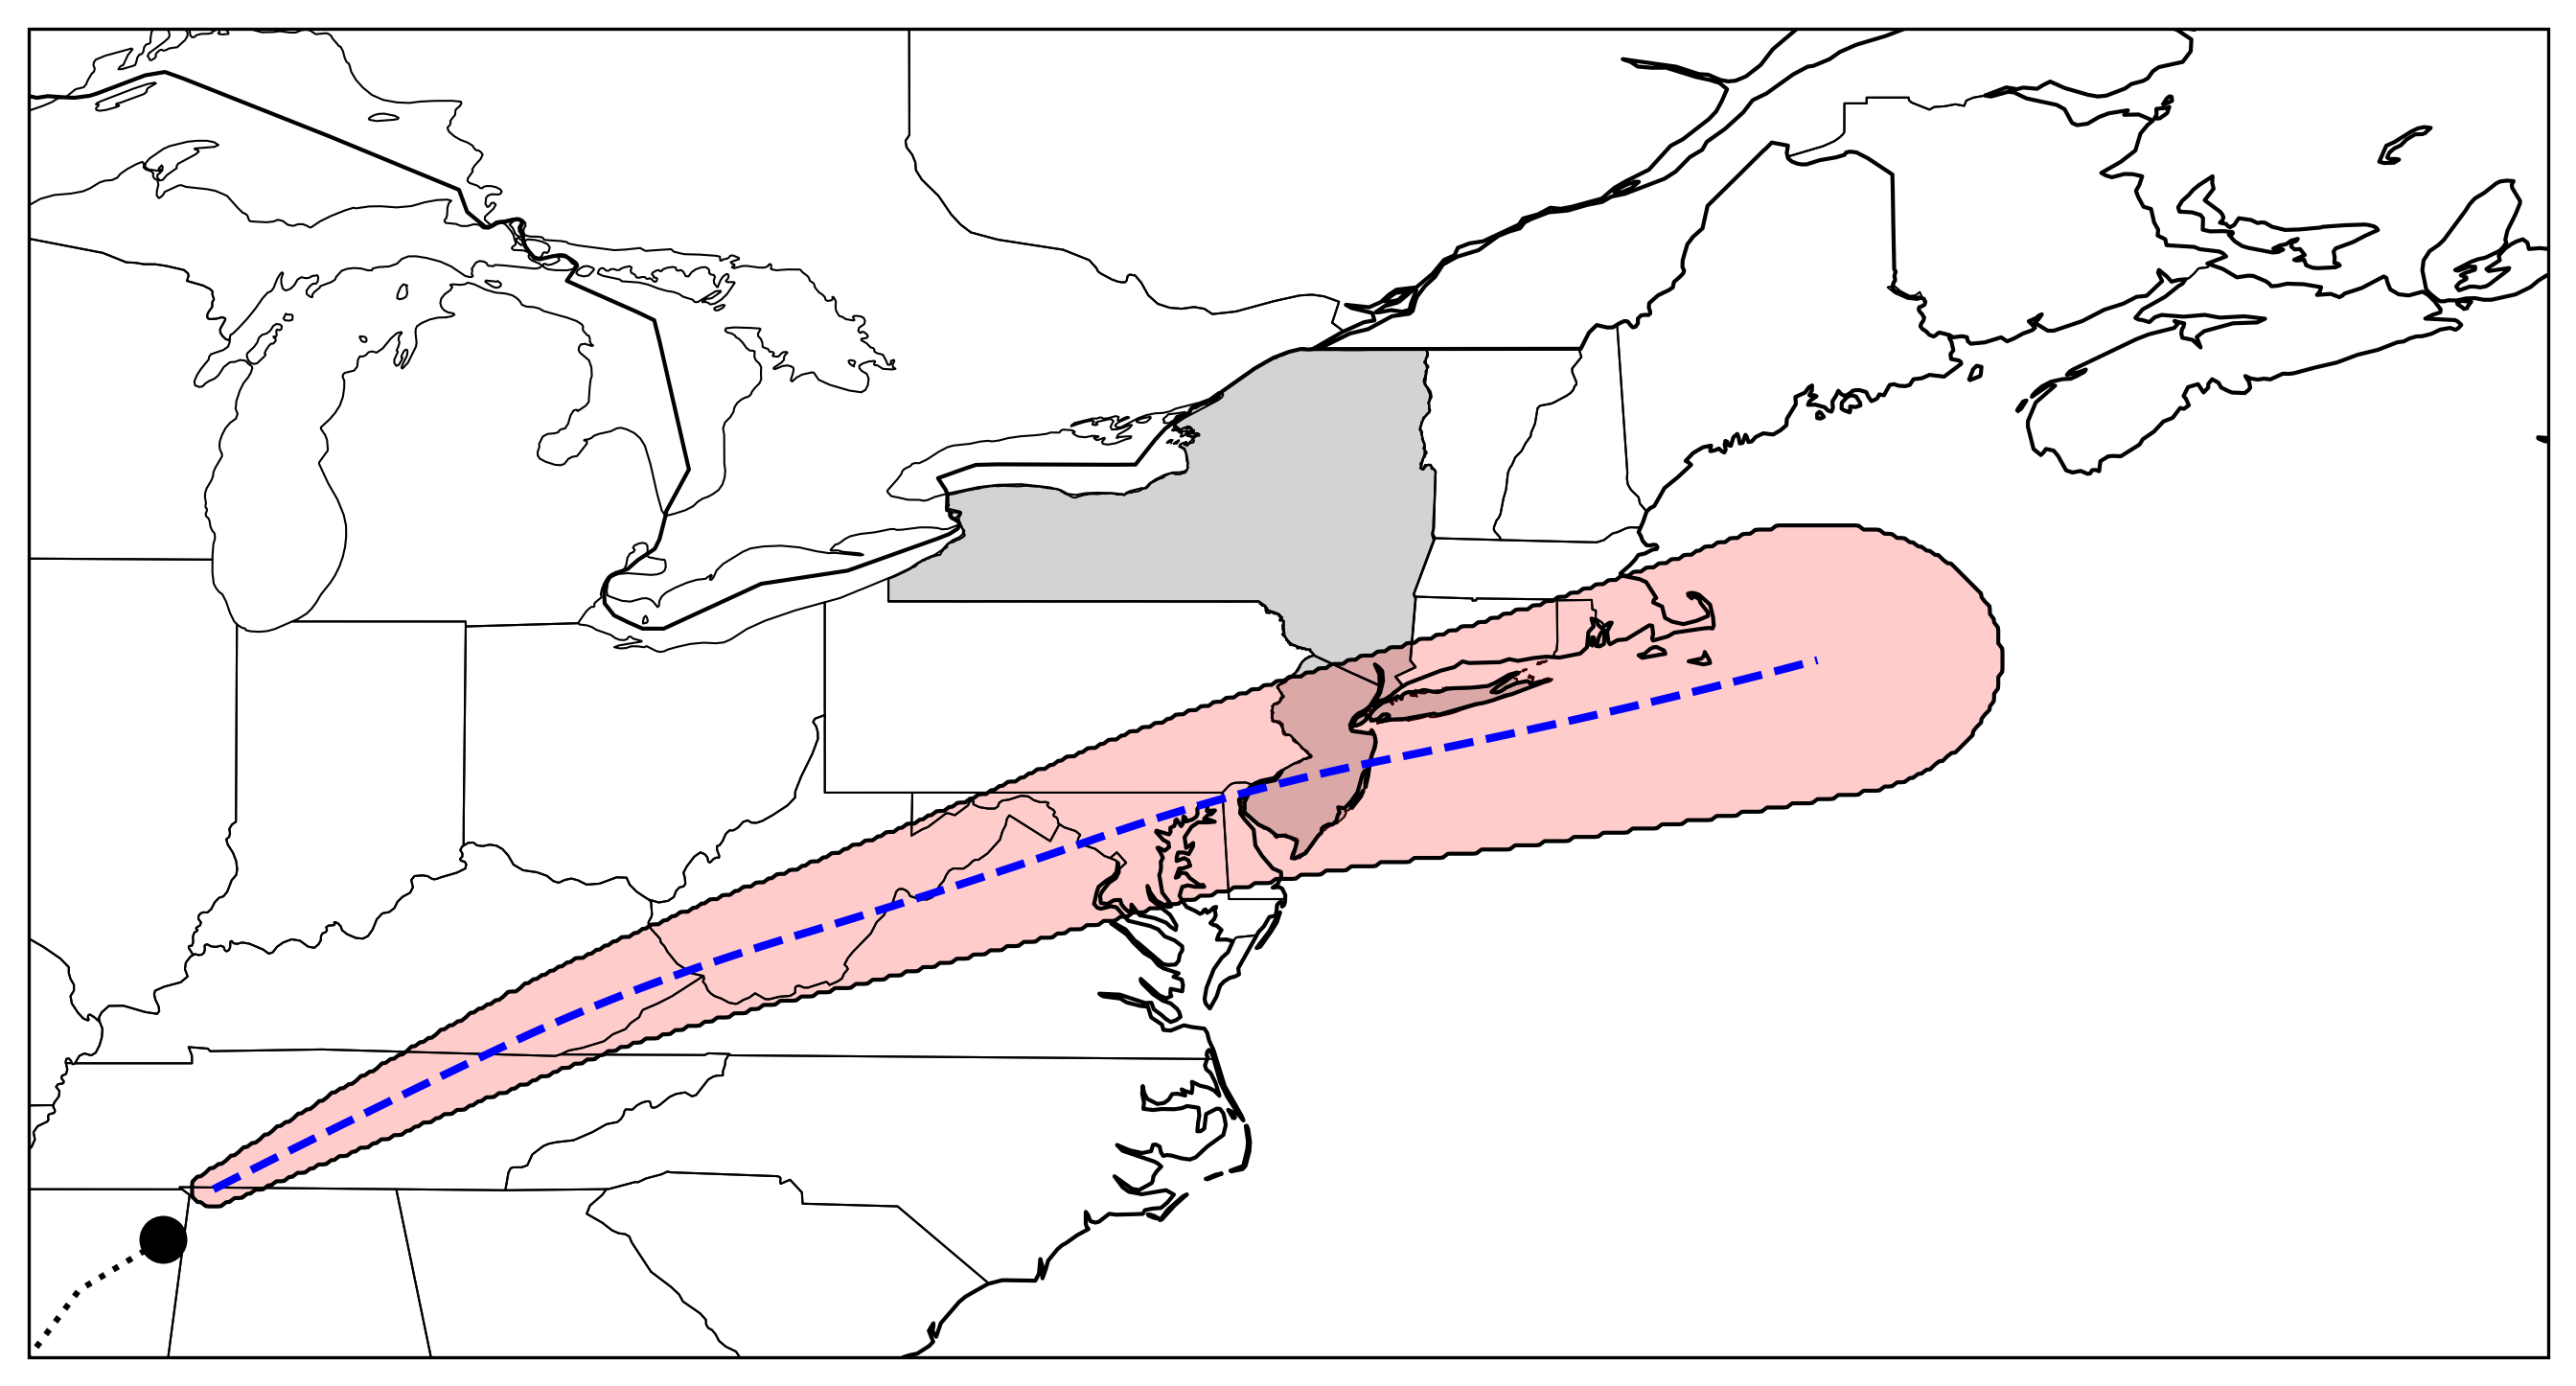

In [22]:
storm = basin.get_storm(('ida',2021))
requested_time = dt.datetime(2021, 8, 31, 12)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)
fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)
ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
nj_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
ny_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-90,-60,33,48])

# Helene

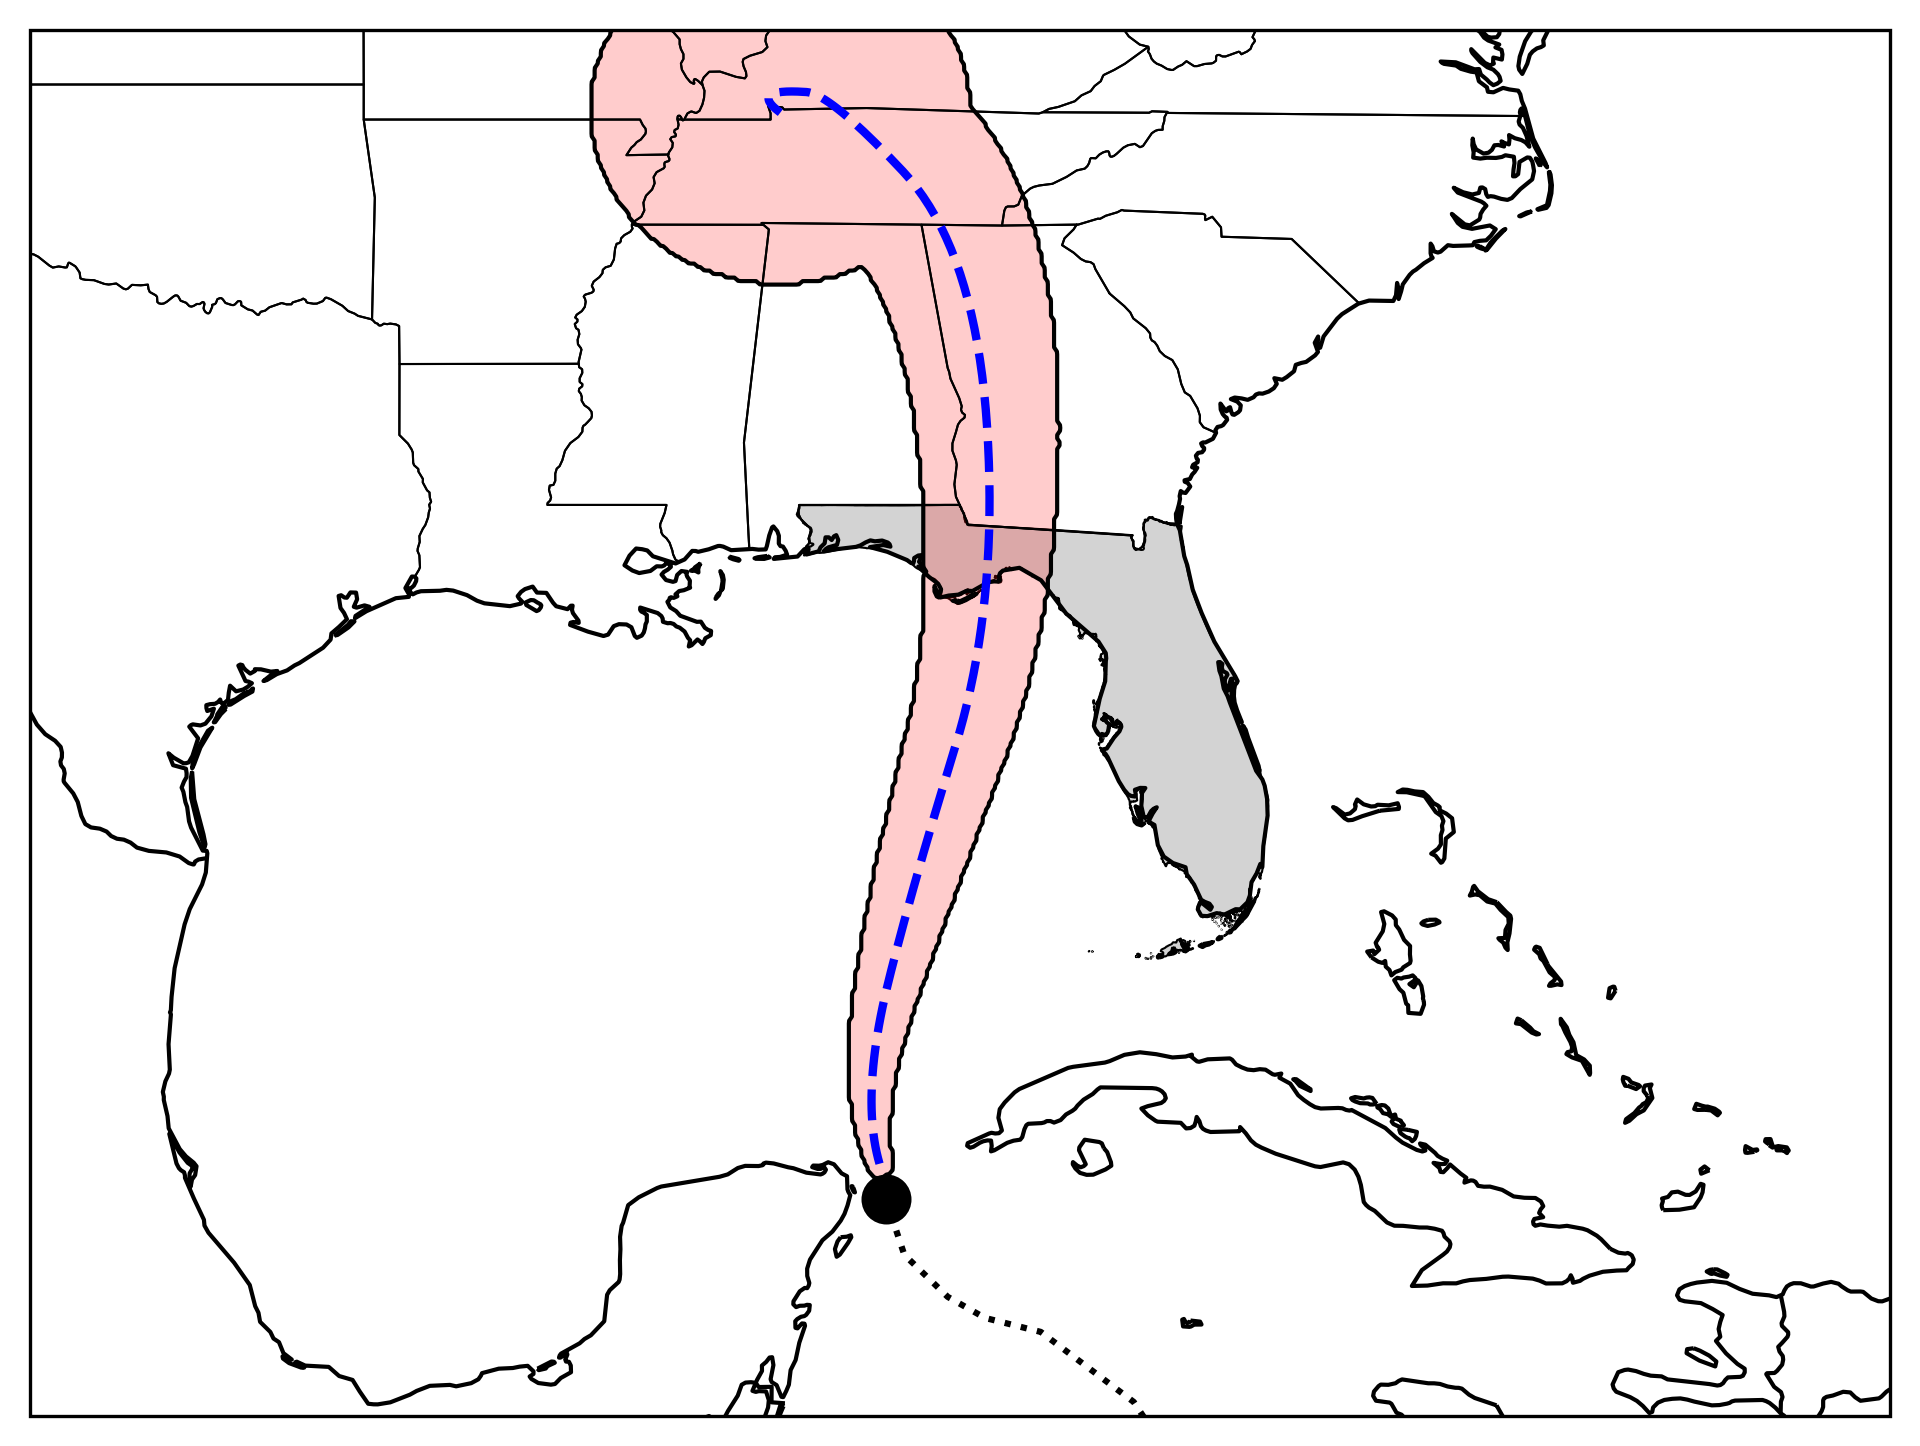

In [23]:
storm = basin.get_storm(('helene',2024))

requested_time = dt.datetime(2024, 9, 25, 12)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)


ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
fl_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())
# Plot Hurricane ida's forecast
ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-100,-70,18,37])

# Milton

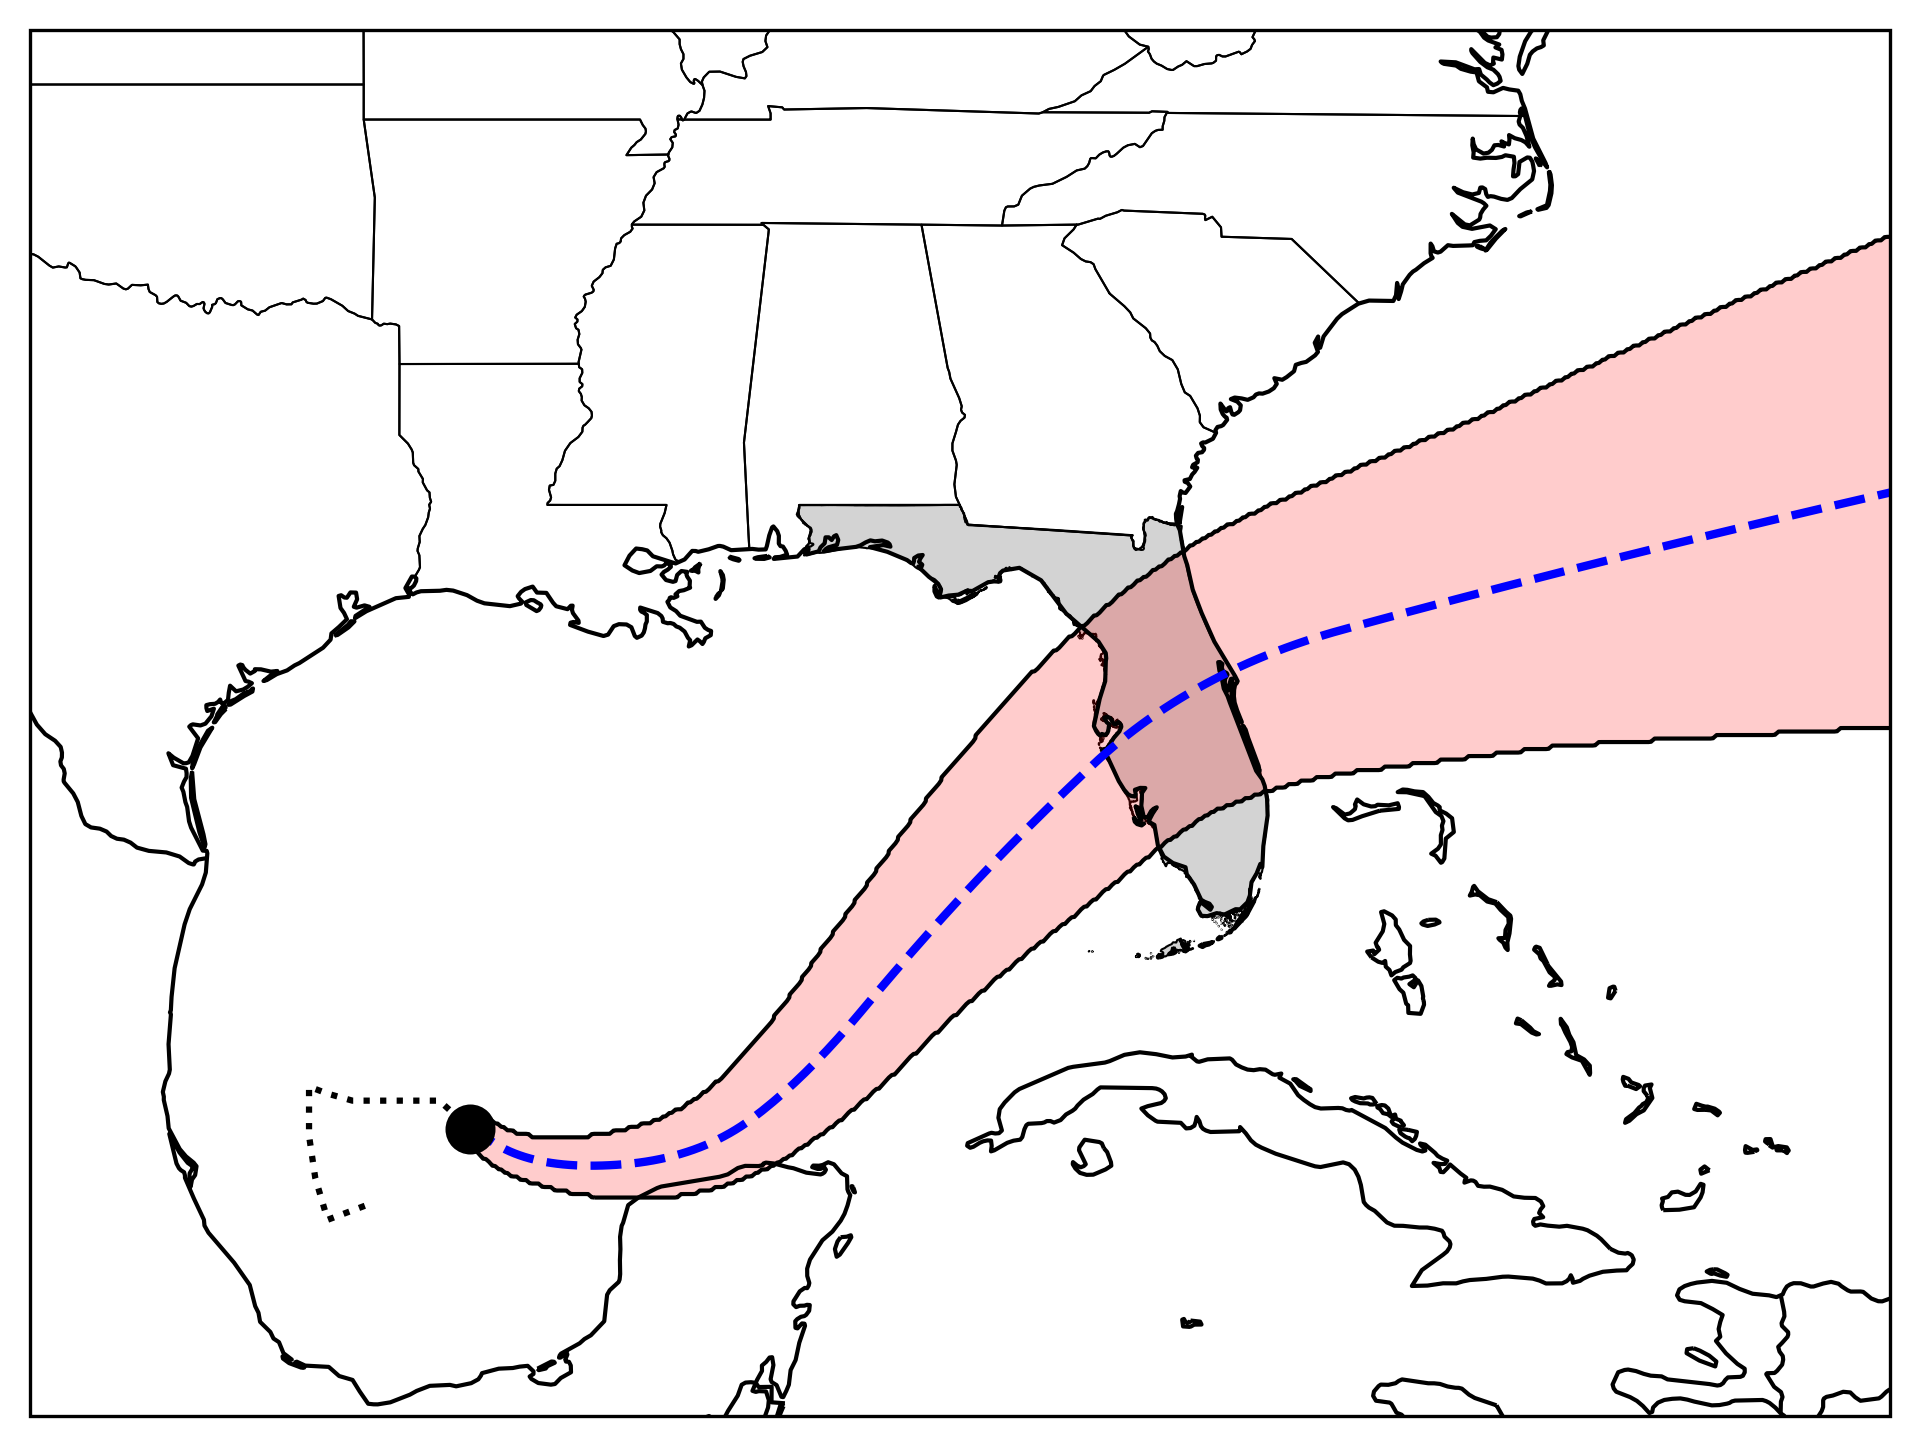

In [24]:
storm = basin.get_storm(('milton',2024))
requested_time = dt.datetime(2024, 10, 7, 8)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)


ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
fl_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')


ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())
ax.set_extent([-100,-70,18,37])

# Laura

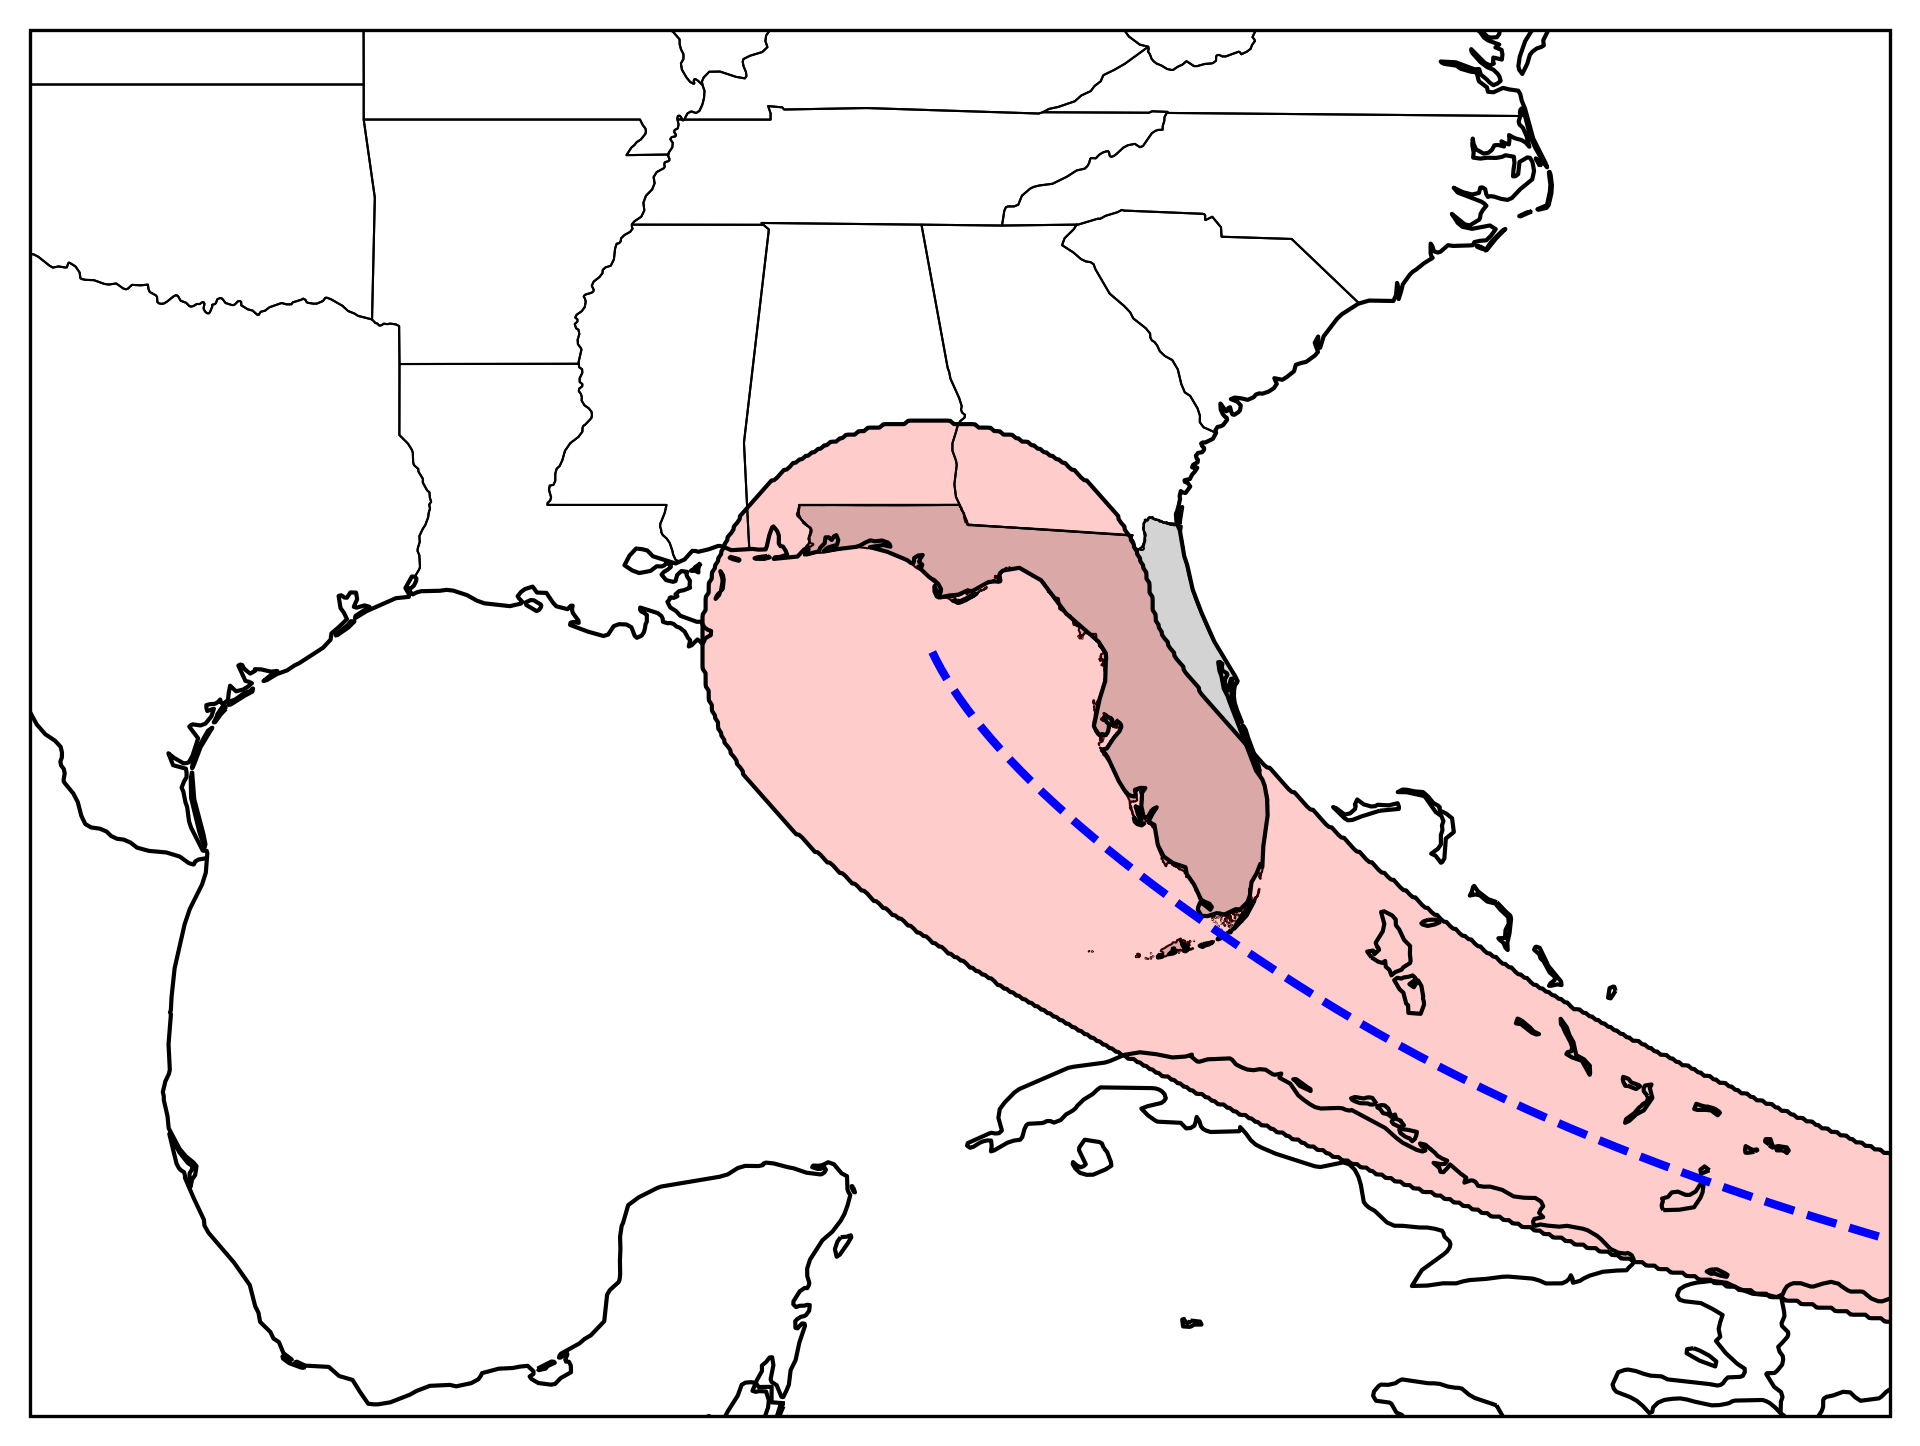

In [25]:
storm = basin.get_storm(('laura',2020))

requested_time = dt.datetime(2020, 8, 21, 0)

cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj) 
ax = plot_boundaries(ax)


ax = utils.add_tropycal(ax)

storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
fl_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-100,-70,18,37])

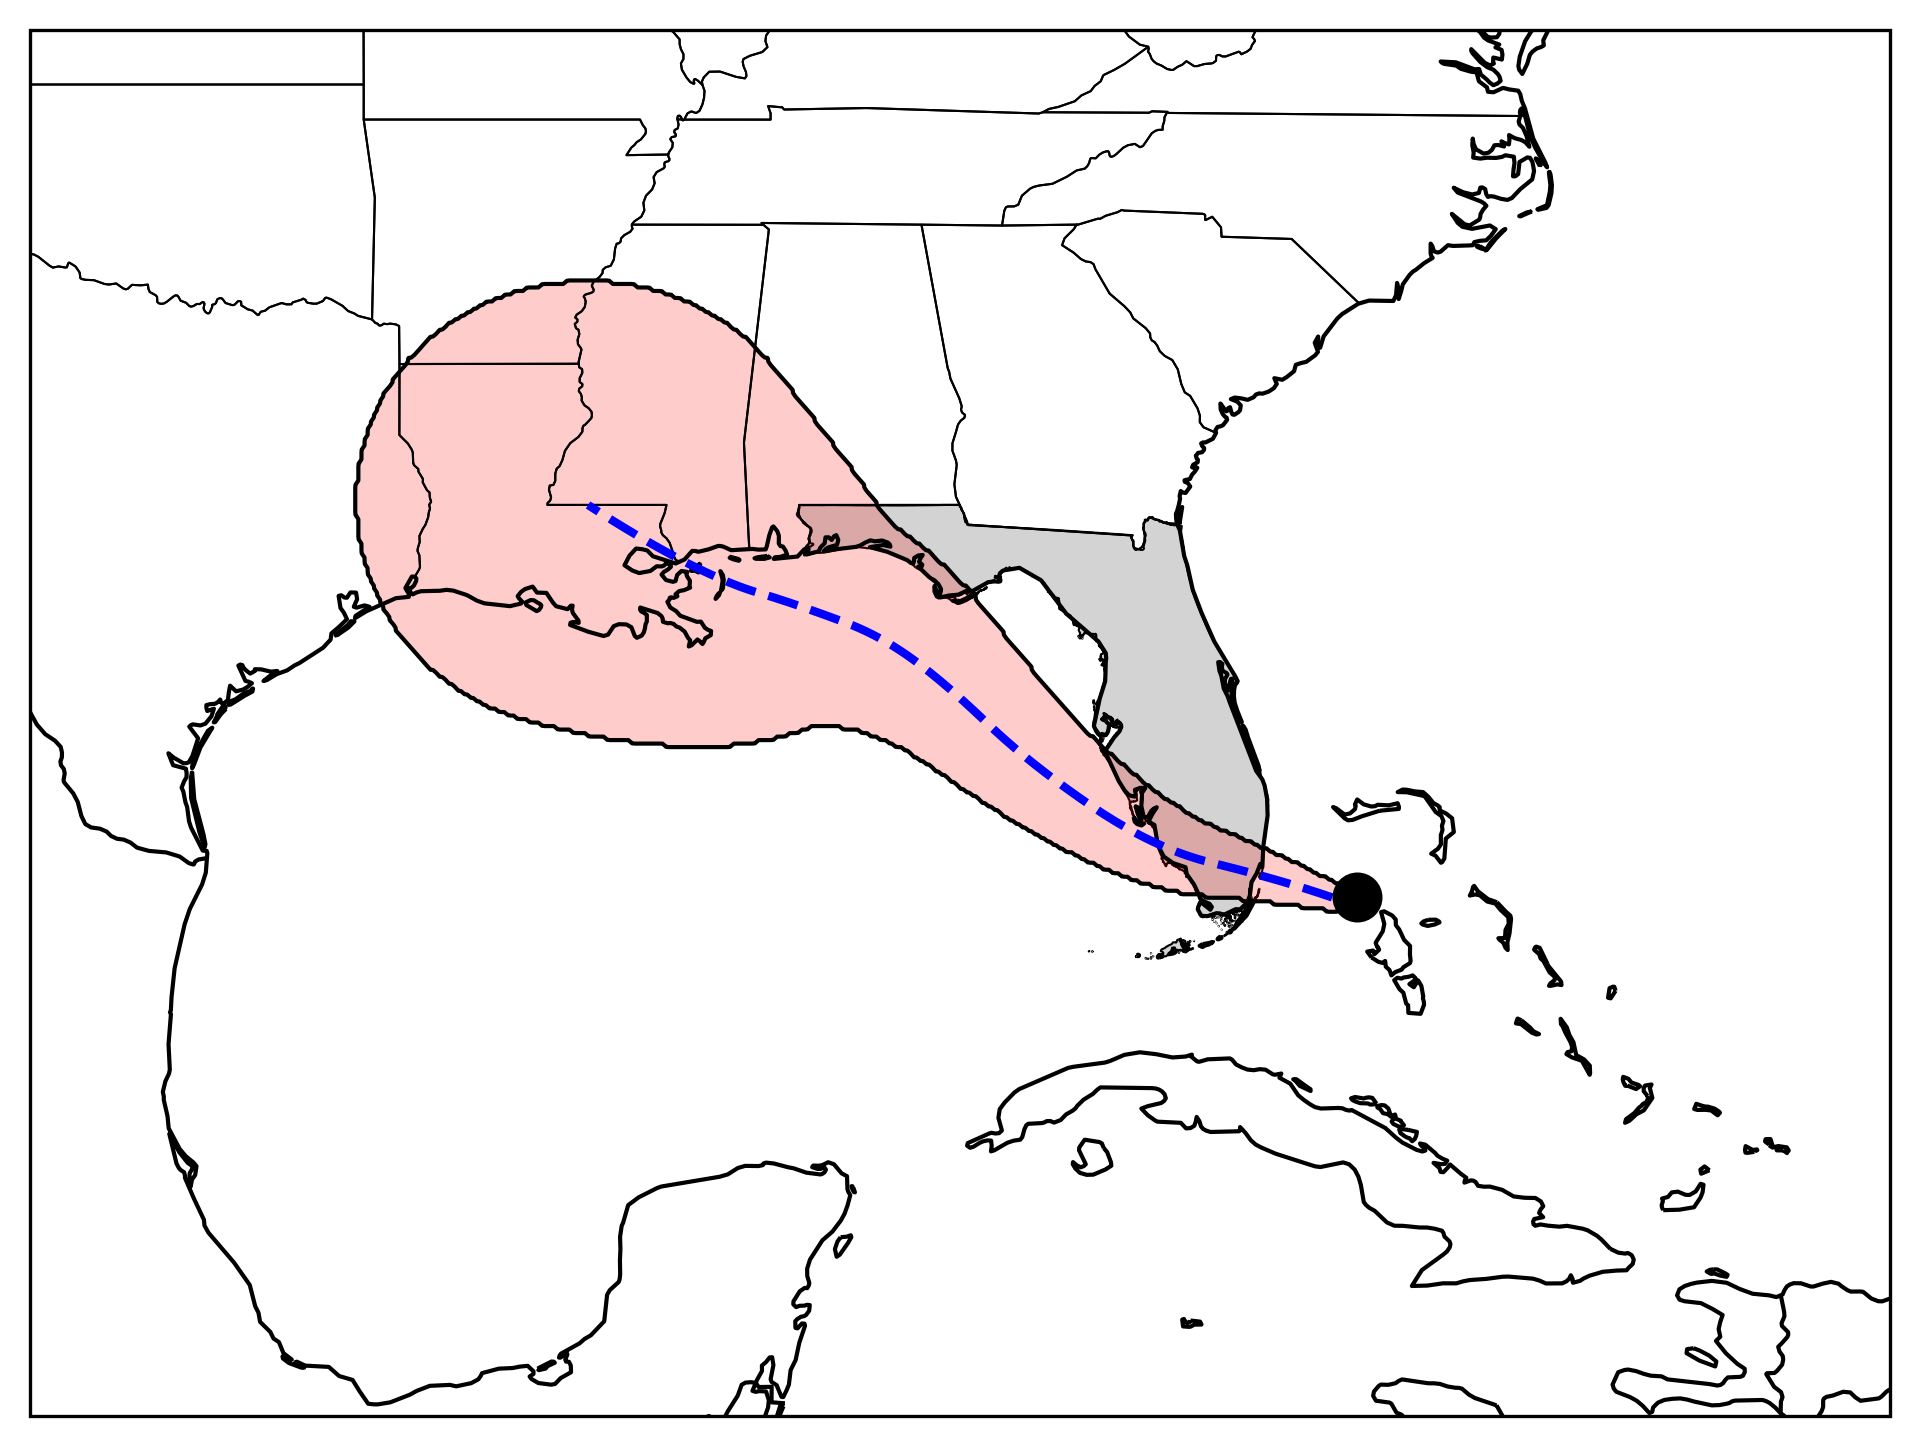

In [26]:

storm = basin.get_storm(('sally',2020))

requested_time = dt.datetime(2020, 9, 11, 18)


cone = utils.generate_nhc_cone(
    forecast = storm.get_nhc_forecast_dict(requested_time),
    basin = 'north_atlantic',
    cone_days = 5,
    return_xarray = True,
)

fig = plt.figure(figsize=(12,6),dpi=300)
ax = plt.axes(projection=proj)
ax = plot_boundaries(ax)


ax = utils.add_tropycal(ax)


storm_subset = storm.sel(time=(storm.time[0],requested_time))
ax.plot_storm(storm_subset, color='k', linestyle='dotted')
fl_mercator.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

ax.plot_cone(cone = cone,
             fillcolor = 'red',
             alpha = 0.2,
             plot_center_line = True,
             center_linecolor = 'blue',
             center_linestyle = 'dashed')

ax.plot(storm_subset.lon[-1], storm_subset.lat[-1], 'o',
        mfc='k', mec='none', ms=12, transform=ccrs.PlateCarree())

ax.set_extent([-100,-70,18,37])